In [8]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

MAX_CATEGORIES_TO_PLOT = 20
MAX_TOP_CATEGORIES = 15
MAX_NUMERIC_FOR_INDIVIDUAL_PLOTS = 20
MAX_NUMERIC_FOR_PAIRPLOT = 8
MAX_ROWS_FOR_PAIRPLOT = 3000
HEATMAP_ANNOT_LIMIT = 25
HEATMAP_MAX_COLUMNS = 60
MIN_UNIQUE_FOR_VIOLIN = 5
MAX_TARGET_CLASSES_FOR_GROUPBY = 15
TARGET_CANDIDATES = [
    "target", "label", "class", "outcome", "species", "y",
    "diagnosis", "result", "output", "loan_status", "class_label",
]


def load_dataset(file_path):
    encodings = ["utf-8", "latin1", "cp1252"]
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(file_path, encoding=encodinperform_edag)
        except Exception as error:
            last_error = error
    raise last_error


def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_overview(df):
    section("DATASET OVERVIEW")
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    print("\nColumns:", df.columns.tolist())
    print("\nData Types:\n", df.dtypes)
    print("\nInfo:")
    df.info()
    print("\nFirst 5 Rows:\n", df.head())
    print("\nLast 5 Rows:\n", df.tail())
    print("\nStatistical Summary:\n", df.describe(include="all").transpose())


def print_missing_and_duplicates(df):
    section("MISSING VALUES & DUPLICATES")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    missing_report = missing_report[missing_report["missing_count"] > 0]
    if missing_report.empty:
        print("No missing values found.")
    else:
        print(missing_report.sort_values("missing_count", ascending=False))
    print("\nDuplicate Rows:", df.duplicated().sum())


def print_unique_counts(df):
    section("UNIQUE VALUE COUNTS")
    print(df.nunique().sort_values(ascending=False))


def detect_column_types(df, target=None):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target]
    categorical_cols = [c for c in categorical_cols if c != target]
    return numeric_cols, categorical_cols


def detect_target_column(df, target=None):
    if target and target in df.columns:
        return target
    lower_map = {c.lower(): c for c in df.columns}
    for candidate in TARGET_CANDIDATES:perform_eda
        if candidate in lower_map:
            return lower_map[candidate]
    last_col = df.columns[-1]
    unique_count = df[last_col].nunique()
    unique_ratio = unique_count / len(df) if len(df) else 1
    if 1 < unique_count <= 20 and unique_ratio < 0.05:
        return last_col
    return None


def print_target_distribution(df, target):
    section(f"TARGET DISTRIBUTION: {target}")
    counts = df[target].value_counts()
    percentages = (df[target].value_counts(normalize=True) * 100).round(2)
    print(pd.DataFrame({"count": counts, "percentage": percentages}))
    if df[target].nunique() <= MAX_CATEGORIES_TO_PLOT:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=target, order=counts.index)
        plt.title(f"Distribution of {target}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


def detect_image_dataset(df, target=None):
    numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target]
    n = len(numeric_cols)
    side = int(round(np.sqrt(n)))
    if n >= 64 and side * side == n:
        col_min = df[numeric_cols].min().min()
        col_max = df[numeric_cols].max().max()
        if col_min >= 0 and col_max <= 255:
            return numeric_cols, side
    return None, None


def handle_image_dataset(df, pixel_cols, side, target):
    section("IMAGE DATASET DETECTED")perform_eda
    print(f"Detected {len(pixel_cols)} pixel columns forming {side}x{side} images.")

    sample_count = min(10, len(df))
    plt.figure(figsize=(12, 5))
    for i in range(sample_count):
        plt.subplot(2, 5, i + 1)
        image = df.iloc[i][pixel_cols].values.reshape(side, side)
        plt.imshow(image, cmap="gray")
        plt.axis("off")
        if target:
            plt.title(str(df.iloc[i][target]))
    plt.tight_layout()
    plt.show()

    pixel_sample = df[pixel_cols].values.flatten()
    if pixel_sample.size > 200000:
        pixel_sample = np.random.choice(pixel_sample, 200000, replace=False)

    plt.figure(figsize=(8, 5))
    sns.histplot(pixel_sample, bins=40)
    plt.title("Pixel Intensity Distribution")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=pixel_sample)
    plt.title("Pixel Intensity Boxplot")
    plt.tight_layout()
    plt.show()

    if target:
        print_target_distribution(df, target)


def detect_text_columns(df):
    object_cols = df.select_dtypes(include="object").columns.tolist()
    text_col = None
    best_avg_len = 0
    for col in object_cols:
        lengths = df[col].dropna().astype(str).str.len()
        if lengths.empty:
            continue
        avg_len = lengths.mean()
        if avg_len > 20 and avg_len > best_avg_len and df[col].nunique() > 0.3 * len(df):
            text_col = col
            best_avg_len = avg_len
    label_col = None
    for col in object_cols:
        if col != text_col and 1 < df[col].nunique() <= 10:
            label_col = col
            break
    return text_col, label_col


def handle_text_dataset(df, text_col, label_col):
    section("TEXT DATASET DETECTED")
    print(f"Text column: {text_col}")
    df = df.assign(_text_length=df[text_col].astype(str).str.len())

    plt.figure(figsize=(8, 5))
    sns.histplot(df["_text_length"], kde=True, bins=30)
    plt.title(f"{text_col} Length Distribution")perform_eda
    plt.tight_layout()
    plt.show()

    if label_col:
        print_target_distribution(df, label_col)

        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x=label_col, y="_text_length")
        plt.title(f"{text_col} Length by {label_col}")
        plt.tight_layout()
        plt.show()

        if df[label_col].nunique() <= 6:
            plt.figure(figsize=(8, 5))
            sns.violinplot(data=df, x=label_col, y="_text_length")
            plt.title(f"{text_col} Length Distribution by {label_col}")
            plt.tight_layout()
            plt.show()

        print(df.groupby(label_col)["_text_length"].describe())


def plot_numeric_distributions(df, numeric_cols):
    section("NUMERICAL FEATURE DISTRIBUTIONS")
    columns_to_plot = numeric_cols[:MAX_NUMERIC_FOR_INDIVIDUAL_PLOTS]
    if len(numeric_cols) > MAX_NUMERIC_FOR_INDIVIDUAL_PLOTS:
        print(f"Too many numeric columns ({len(numeric_cols)}); plotting first {MAX_NUMERIC_FOR_INDIVIDUAL_PLOTS}.")

    for col in columns_to_plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f"Histogram - {col}")
        plt.tight_layout()
        plt.show()

    for col in columns_to_plot:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot - {col}")
        plt.tight_layout()
        plt.show()

    for col in columns_to_plot:
        if df[col].nunique() >= MIN_UNIQUE_FOR_VIOLIN:
            plt.figure(figsize=(8, 4))
            sns.violinplot(x=df[col])
            plt.title(f"Violin Plot - {col}")
            plt.tight_layout()
            plt.show()


def plot_categorical_distributions(df, categorical_cols):
    section("CATEGORICAL FEATURE DISTRIBUTIONS")
    for col in categorical_cols:
        unique_count = df[col].nunique()

        if unique_count == len(df):
            print(f"{col}: appears to be a unique identifier ({unique_count} unique values); skipping plot.")
            continue

        if unique_count > MAX_CATEGORIES_TO_PLOT:
            print(f"{col}: {unique_count} unique values, showing top {MAX_TOP_CATEGORIES} only.")
            top_categories = df[col].value_counts().head(MAX_TOP_CATEGORIES)
            plt.figure(figsize=(8, 5))
            sns.barplot(x=top_categories.values, y=top_categories.index)
            plt.title(f"Top Categories - {col}")
            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(8, 5))
            sns.countplot(data=df, x=col, order=df[col].value_counts().index)
            plt.title(f"Countplot - {col}")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


def compute_numeric_summary(df, numeric_cols):
    subset = df[numeric_cols]
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((subset < lower_bound) | (subset > upper_bound)).sum()
    zero_counts = (subset == 0).sum()

    summary = pd.DataFrame({
        "mean": subset.mean(),
        "median": subset.median(),
        "variance": subset.var(),
        "std": subset.std(),
        "min": subset.min(),
        "max": subset.max(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "skewness": subset.skew(),perform_eda
        "kurtosis": subset.kurtosis(),
        "zero_count": zero_counts,
        "outlier_count": outliers,
    })
    return summary


def print_numeric_summary(df, numeric_cols):
    section("NUMERICAL FEATURE STATISTICS")
    if not numeric_cols:
        print("No numeric columns found.")
        return
    print(compute_numeric_summary(df, numeric_cols))


def plot_correlation(df, numeric_cols, target=None):
    section("CORRELATION ANALYSIS")
    if len(numeric_cols) < 2:
        print("Not enough numeric columns for correlation analysis.")
        return

    working_df = df[numeric_cols].copy()
    target_added = False
    if target:
        if pd.api.types.is_numeric_dtype(df[target]):
            working_df[target] = df[target]
            target_added = True
        elif df[target].nunique() <= 10:
            working_df[target] = pd.factorize(df[target])[0]
            target_added = True

    correlation_matrix = working_df.corr()
    plot_cols = correlation_matrix.shape[1]

    if plot_cols <= HEATMAP_MAX_COLUMNS:
        annotate = plot_cols <= HEATMAP_ANNOT_LIMIT
        plt.figure(figsize=(min(1 + plot_cols, 20), min(1 + plot_cols, 16)))
        sns.heatmap(correlation_matrix, annot=annotate, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Too many numeric columns ({plot_cols}) for a readable heatmap; skipping.")

    if target_added:
        target_correlation = correlation_matrix[target].drop(target).sort_values(key=abs, ascending=False)
        print("\nCorrelation with target:\n", target_correlation)
        print("\nTop correlated features:\n", target_correlation.head(10))


def plot_pairplot(df, numeric_cols, target=None):
    if len(numeric_cols) < 2 or len(numeric_cols) > MAX_NUMERIC_FOR_PAIRPLOT:
        return
    if len(df) > MAX_ROWS_FOR_PAIRPLOT:
        return

    section("PAIRPLOT")
    hue = target if target and df[target].nunique() <= 10 else None
perform_eda    columns = numeric_cols + ([target] if hue else [])
    sns.pairplot(df[columns], hue=hue)
    plt.show()


def plot_qq_plots(df, numeric_cols):
    section("Q-Q PLOTS")
    columns_to_plot = numeric_cols[:MAX_NUMERIC_FOR_INDIVIDUAL_PLOTS]
    for col in columns_to_plot:
        plt.figure(figsize=(6, 6))
        stats.probplot(df[col].dropna(), dist="norm", plot=plt)
        plt.title(f"QQ Plot - {col}")
        plt.tight_layout()
        plt.show()


def print_grouped_summary(df, numeric_cols, target):
    if not target or not numeric_cols:
        return
    if df[target].nunique() > MAX_TARGET_CLASSES_FOR_GROUPBY:
        return
    section(f"FEATURE SUMMARY GROUPED BY {target}")
    print(df.groupby(target)[numeric_cols].describe().transpose())


def perform_eda(file_path, target=None):
    df = load_dataset(file_path)

    print_overview(df)
    print_missing_and_duplicates(df)
    print_unique_counts(df)

    detected_target = detect_target_column(df, target)

    pixel_cols, side = detect_image_dataset(df, detected_target)
    if pixel_cols:
        handle_image_dataset(df, pixel_cols, side, detected_target)
        section("EDA COMPLETED")
        return

    text_col, label_col = detect_text_columns(df)
    if text_col:
        handle_text_dataset(df, text_col, label_col)
        section("EDA COMPLETED")
        return

    numeric_cols, categorical_cols = detect_column_types(df, detected_target)

    if detected_target:
        print_target_distribution(df, detected_target)

    if numeric_cols:
        plot_numeric_distributions(df, numeric_cols)
        print_numeric_summary(df, numeric_cols)
        plot_qq_plots(df, numeric_cols)

    if categorical_cols:
        plot_categorical_distributions(df, categorical_cols)

    if numeric_cols:
        plot_correlation(df, numeric_cols, detected_target)
        plot_pairplot(df, numeric_cols, detected_target)

    print_grouped_summary(df, numeric_cols, detected_target)

    section("EDA COMPLETED")


DATASET OVERVIEW
Shape: 4601 rows x 58 columns

Columns: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char

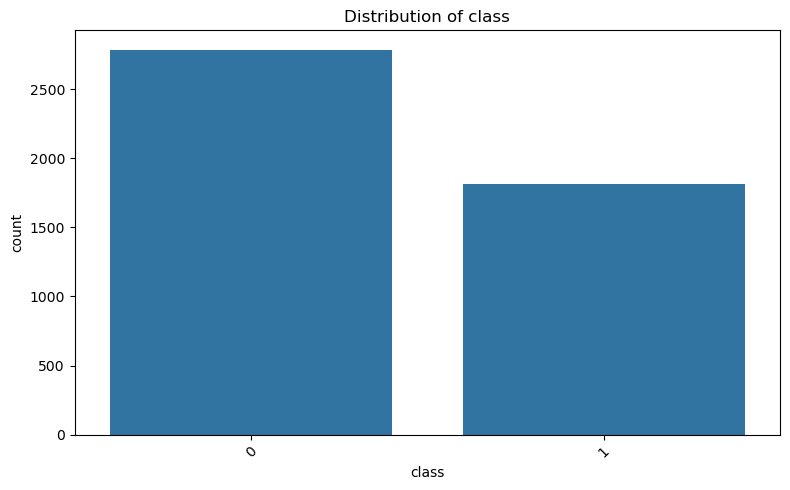


NUMERICAL FEATURE DISTRIBUTIONS
Too many numeric columns (57); plotting first 20.


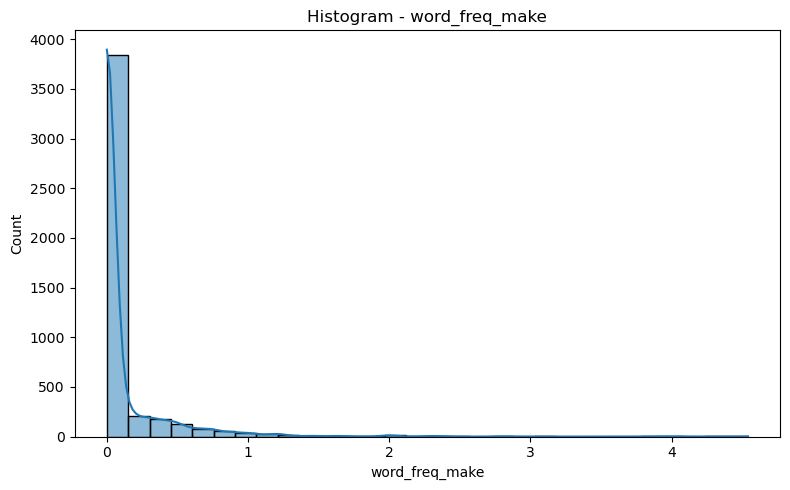

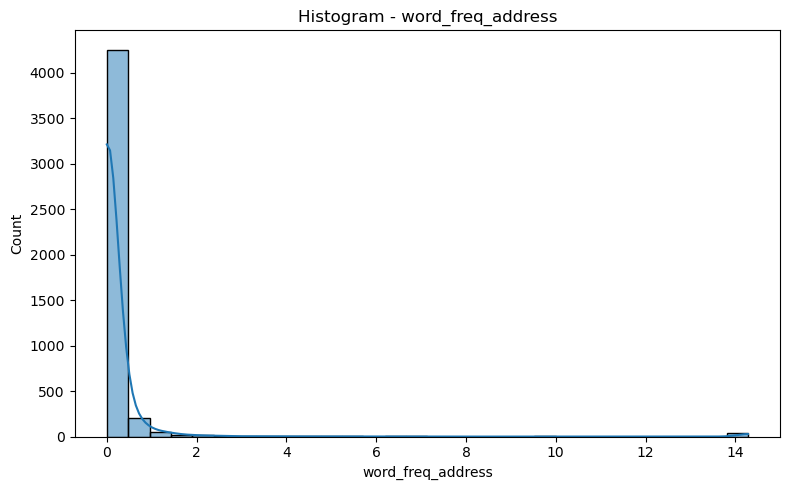

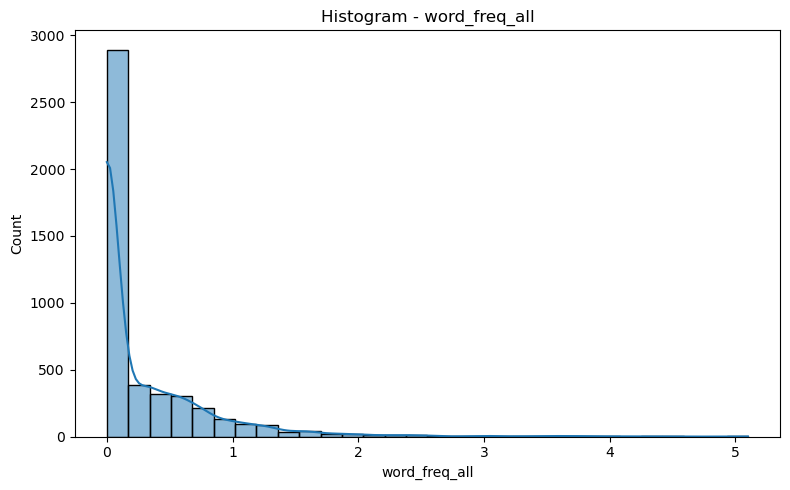

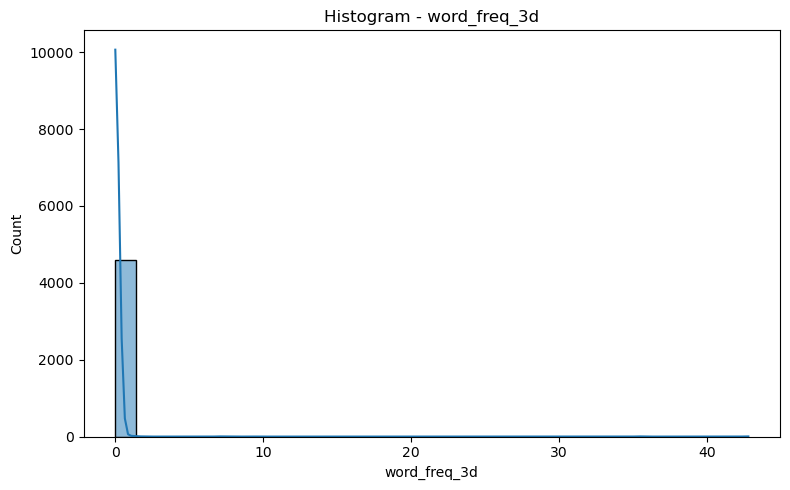

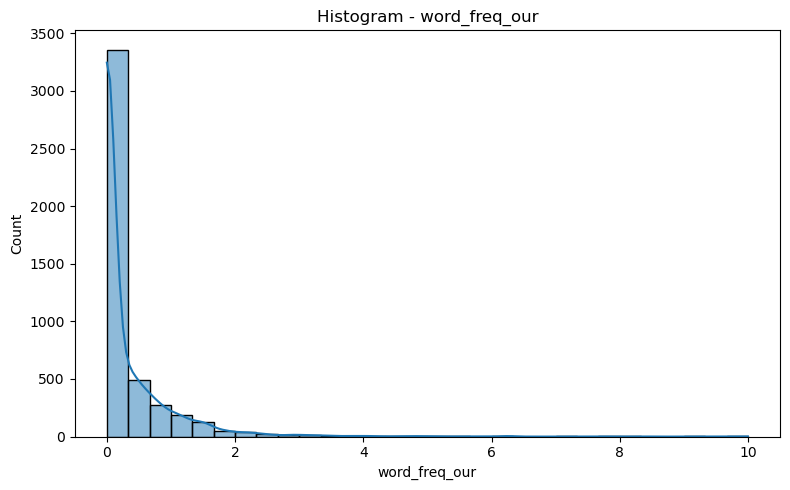

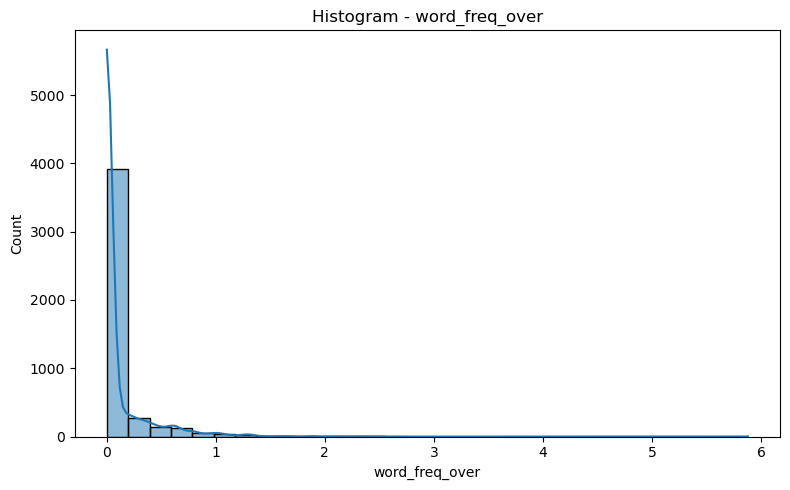

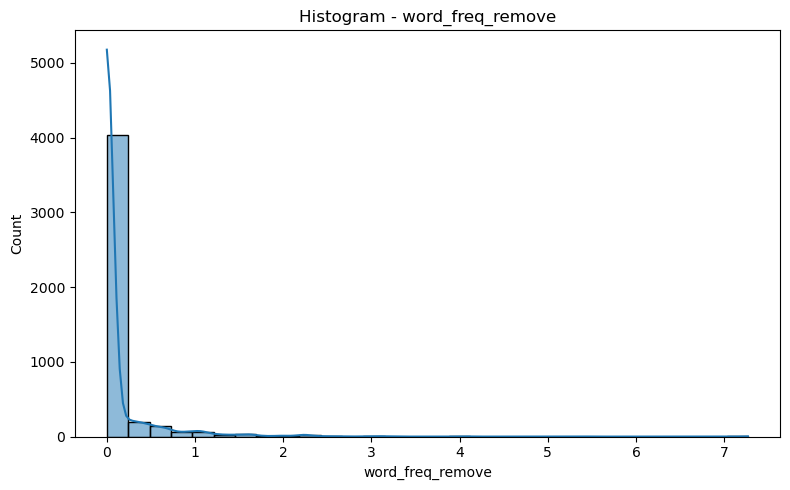

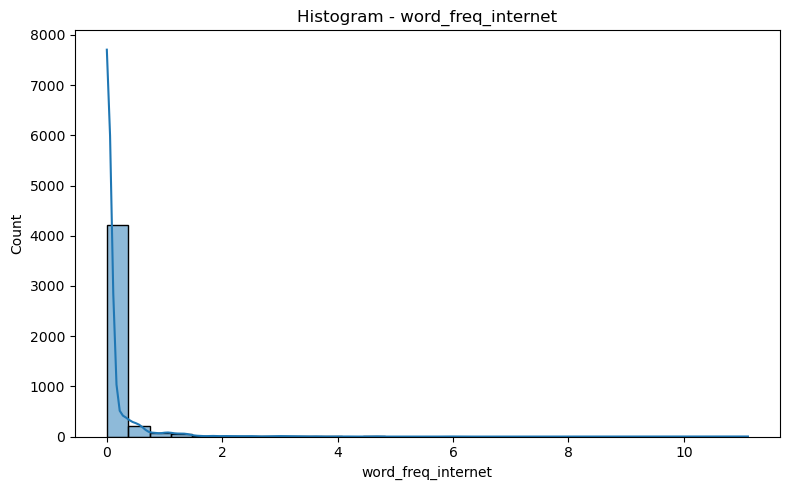

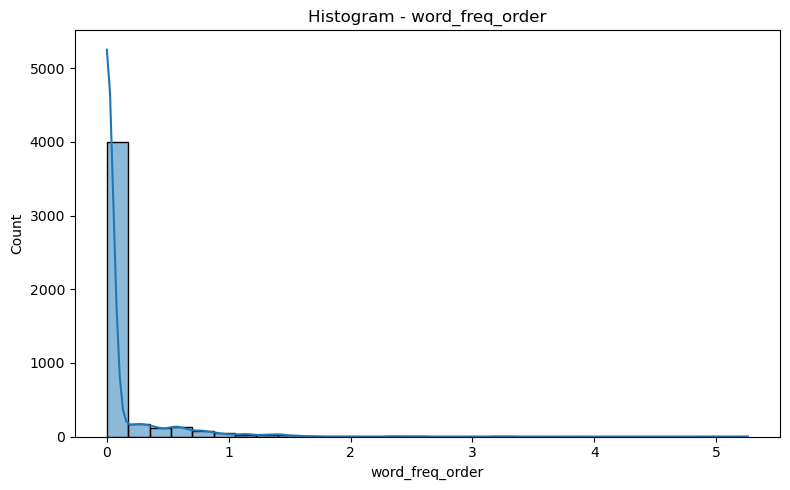

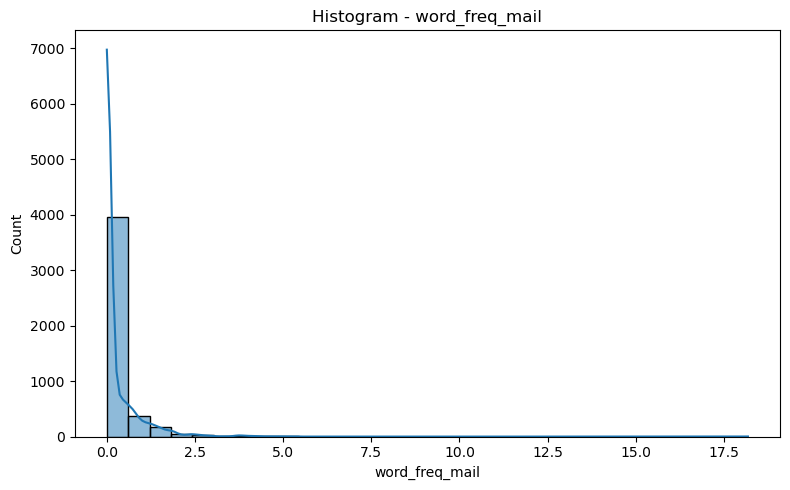

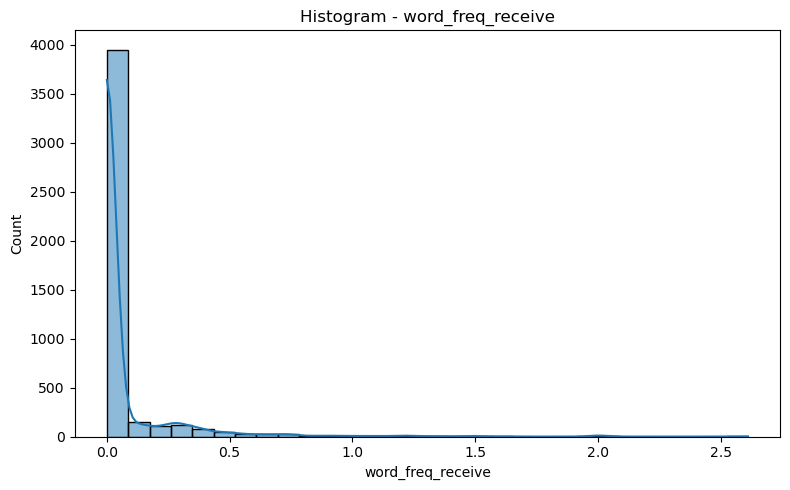

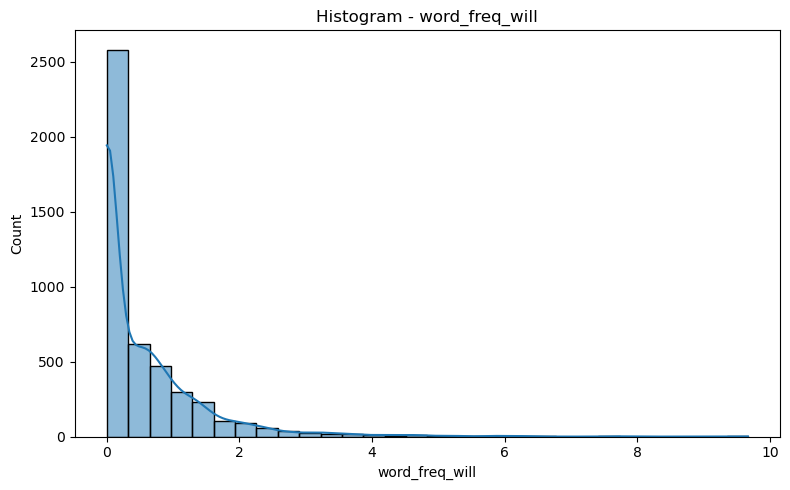

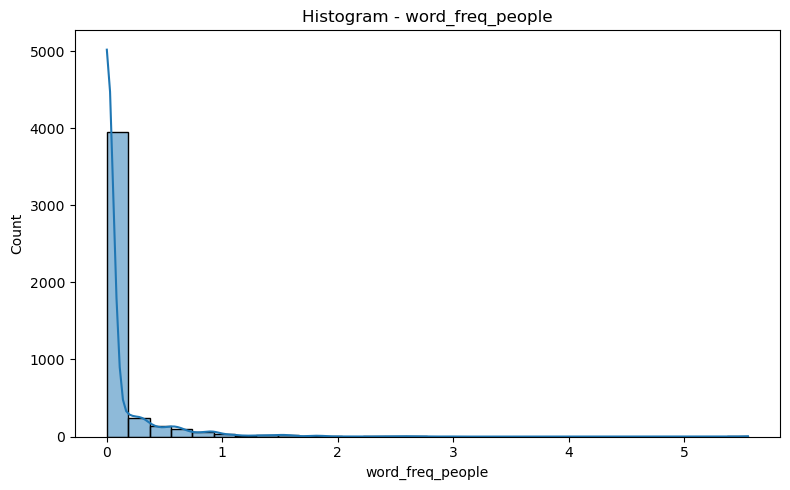

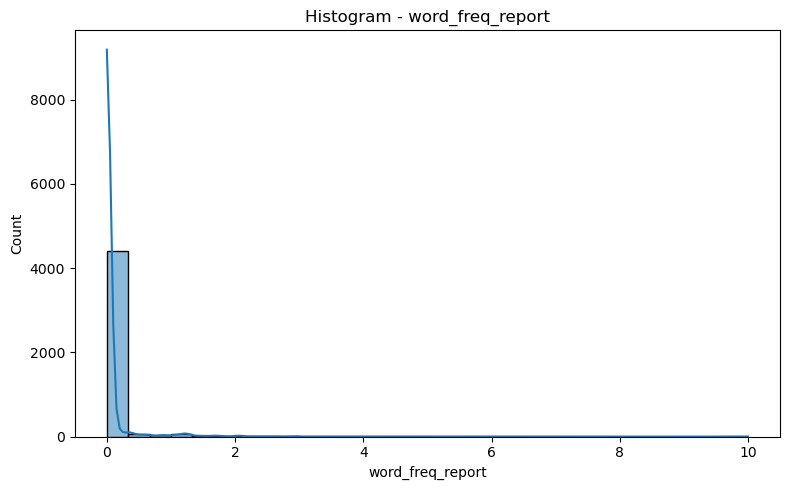

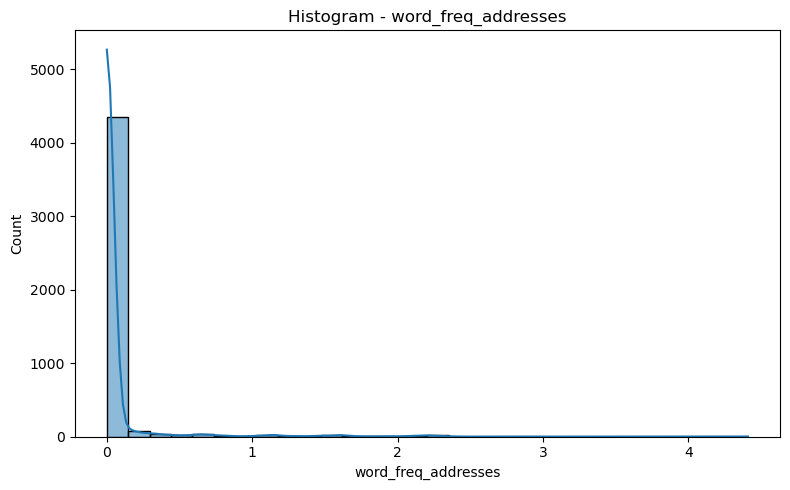

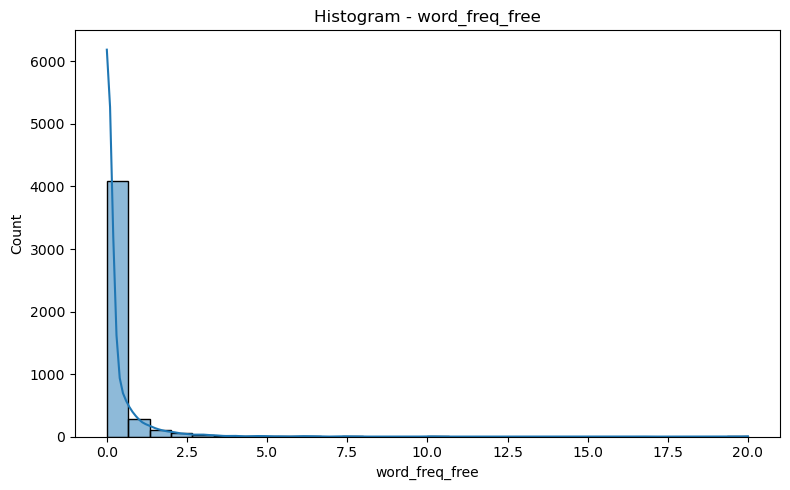

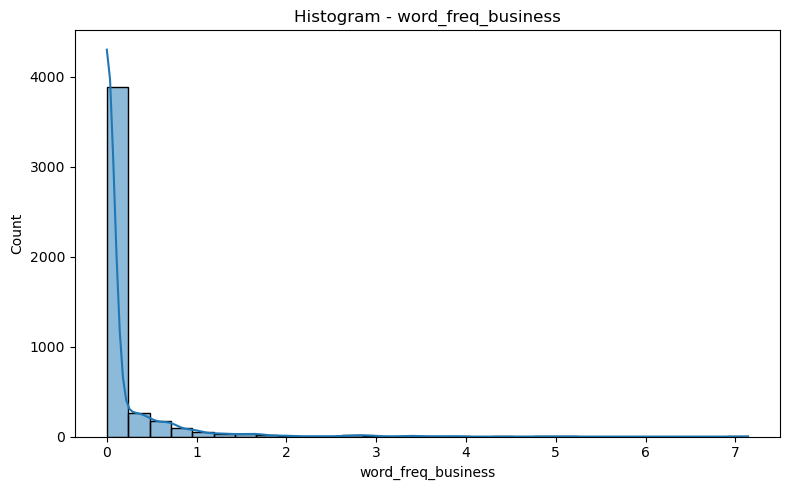

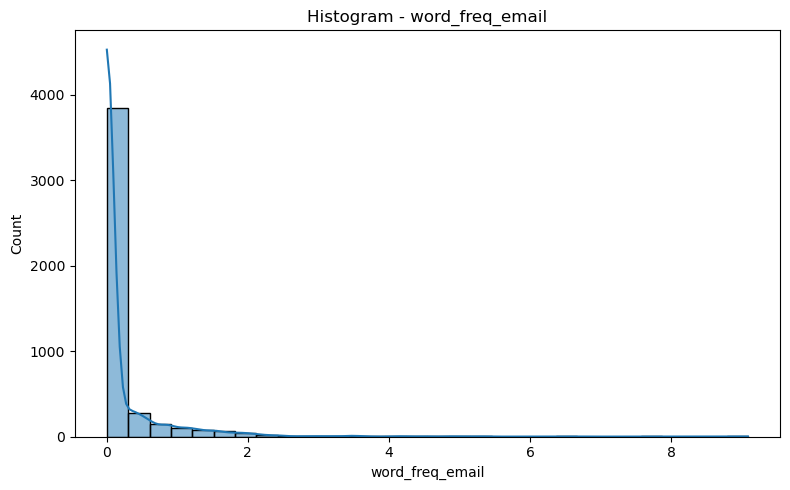

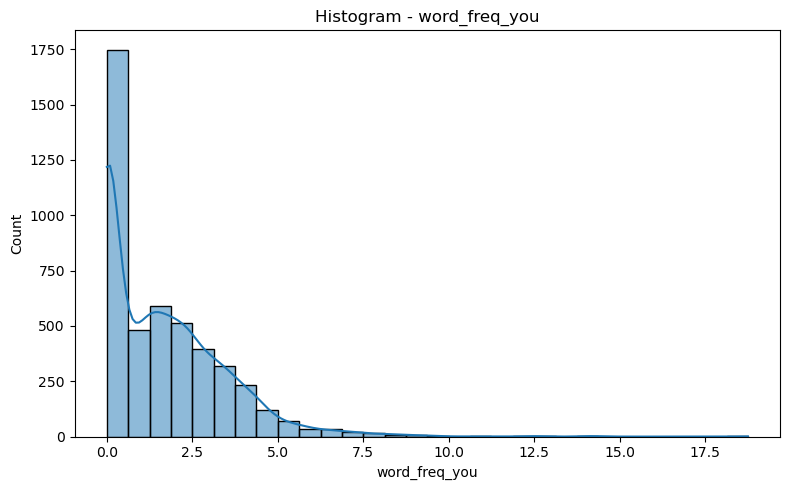

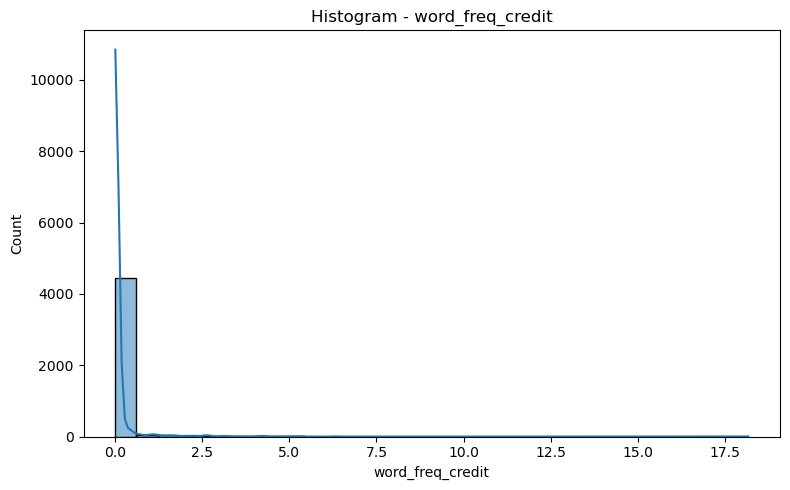

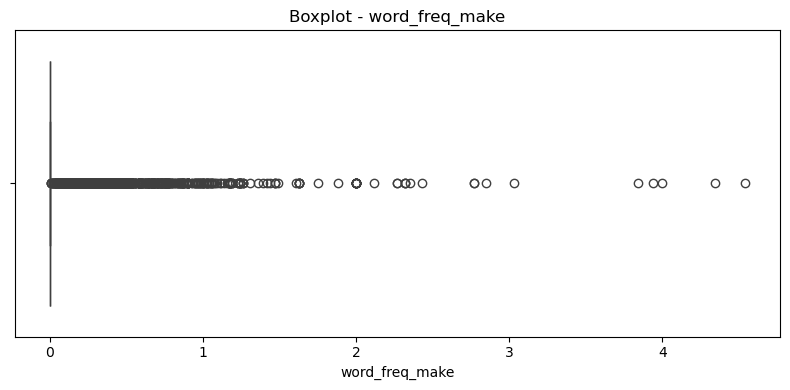

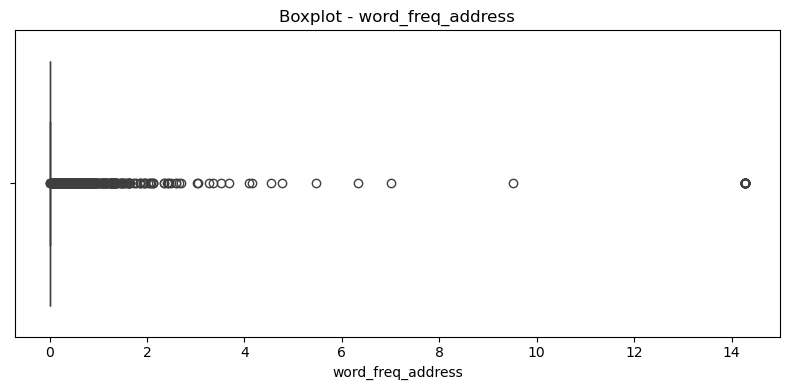

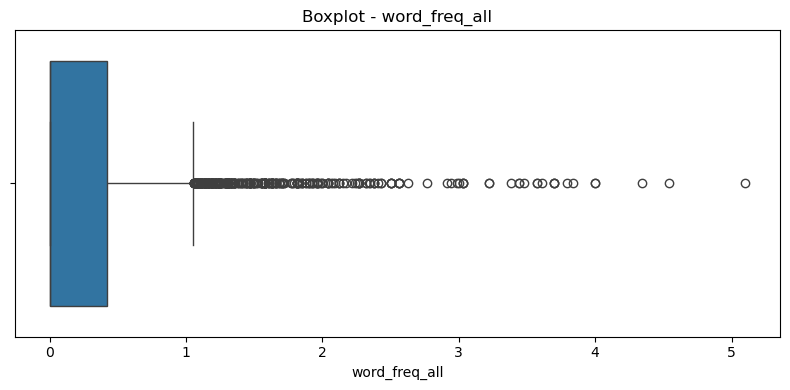

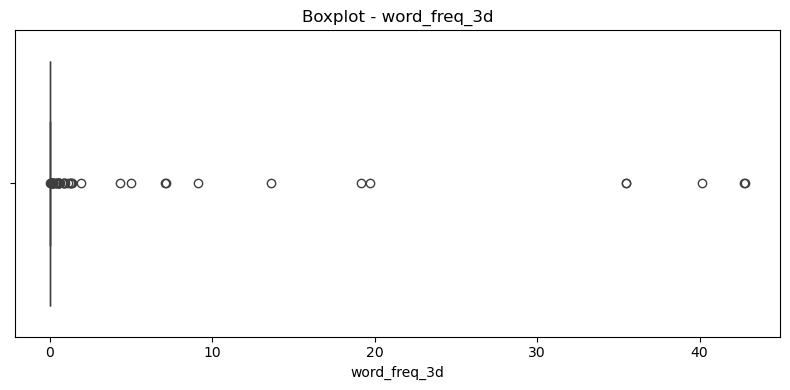

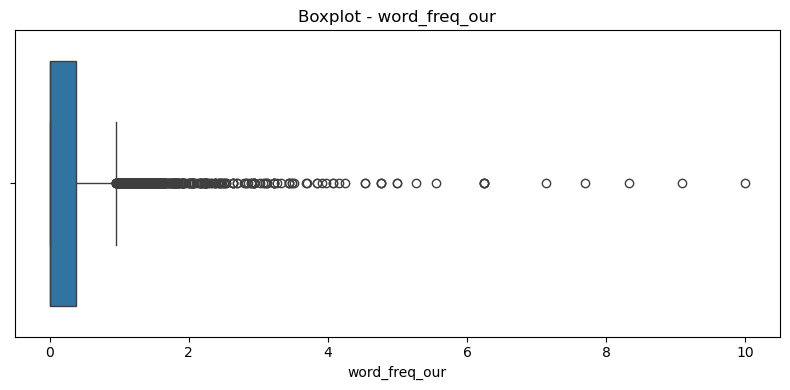

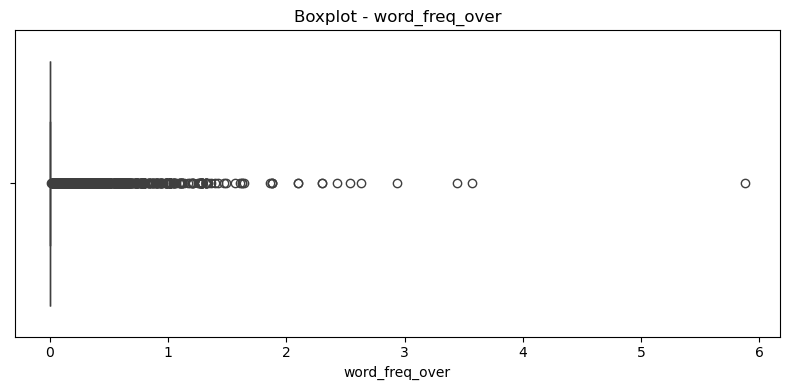

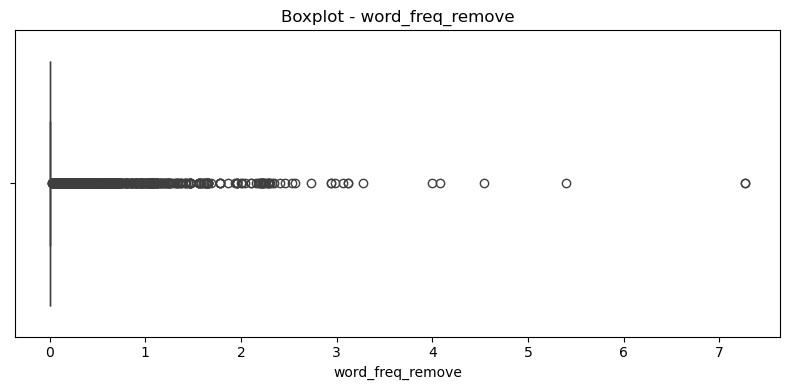

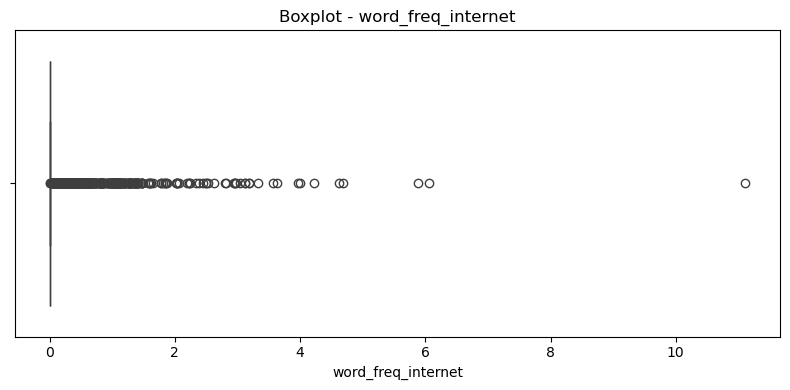

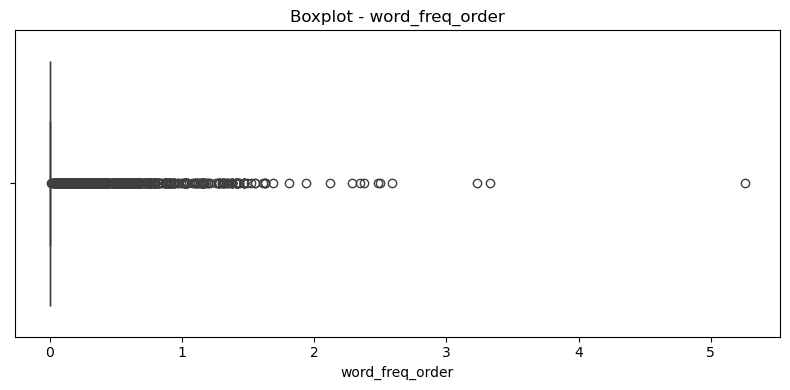

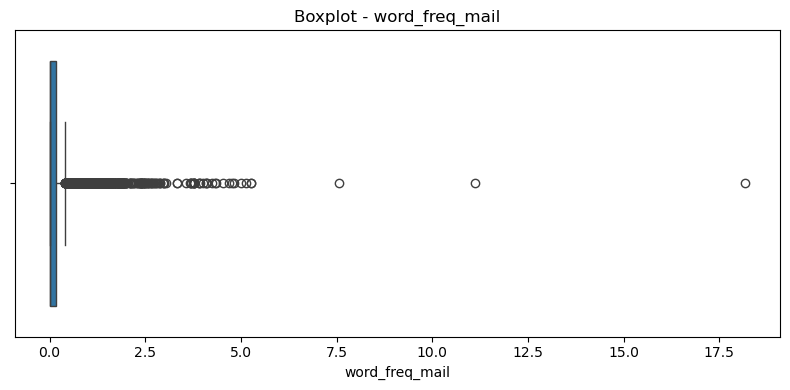

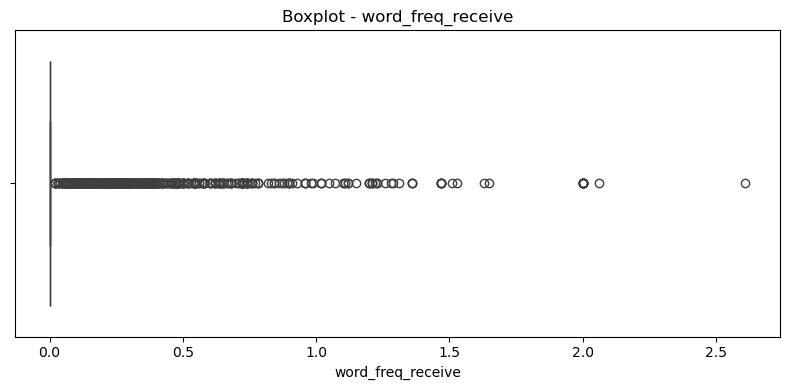

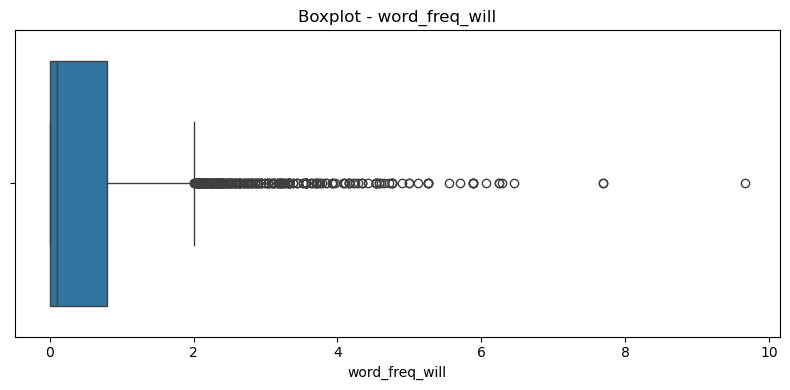

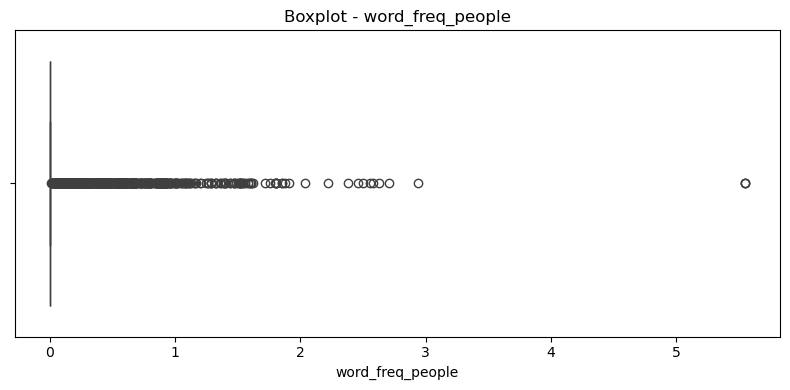

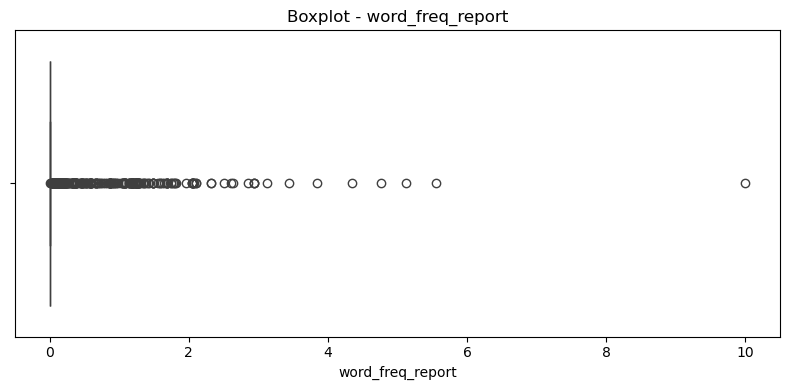

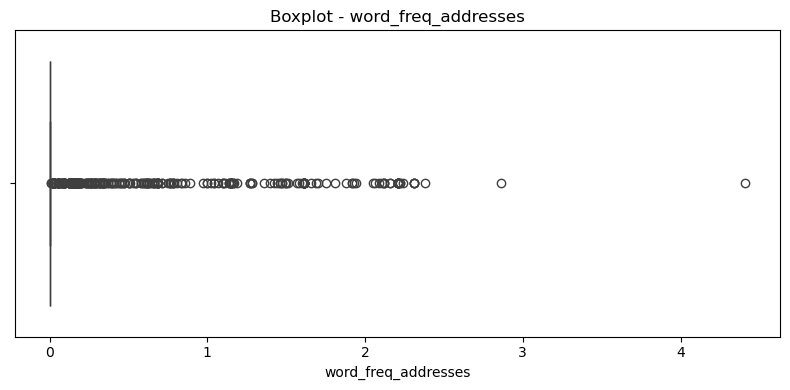

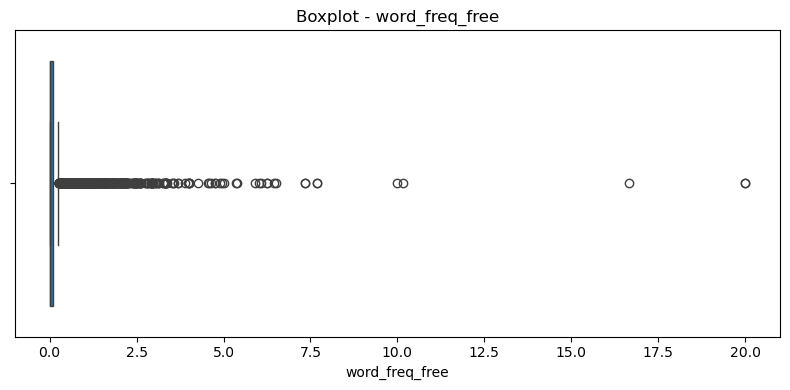

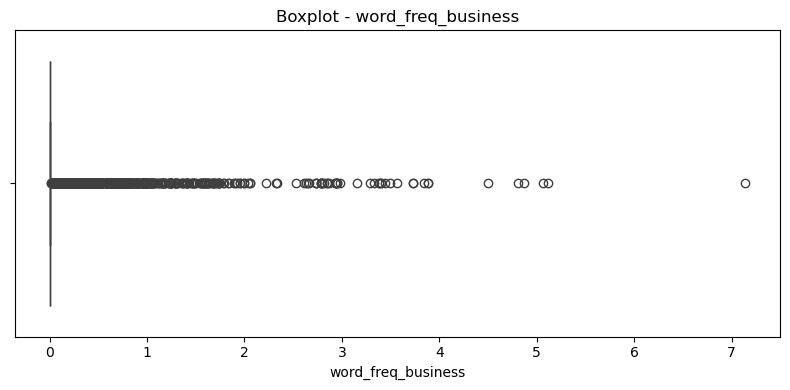

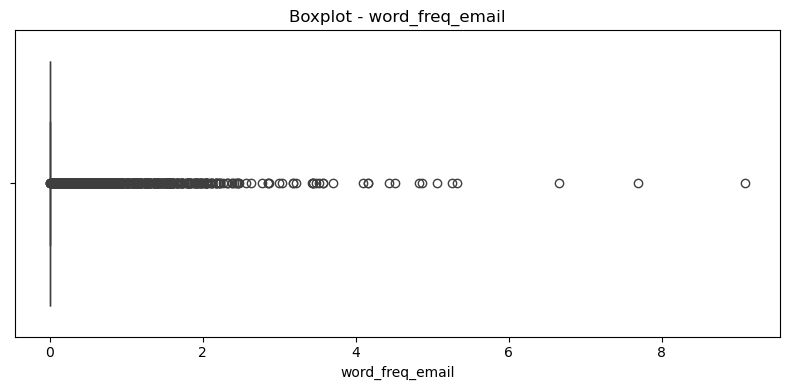

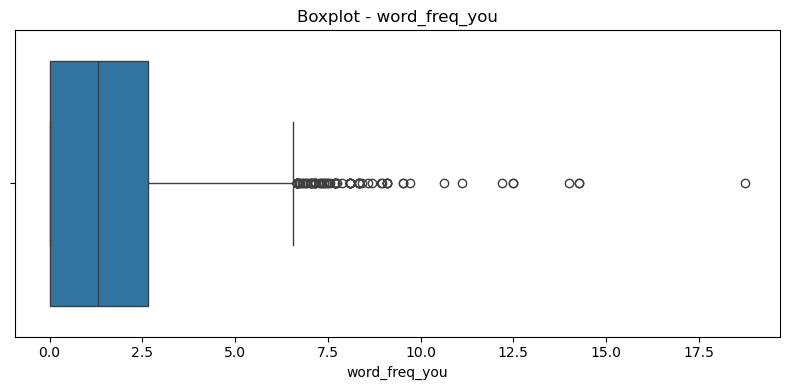

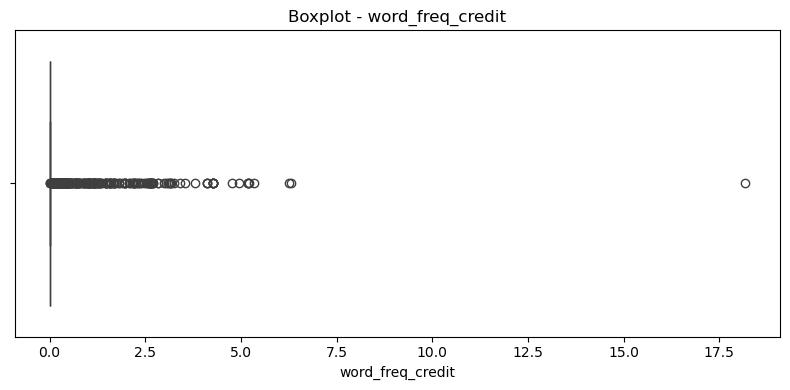

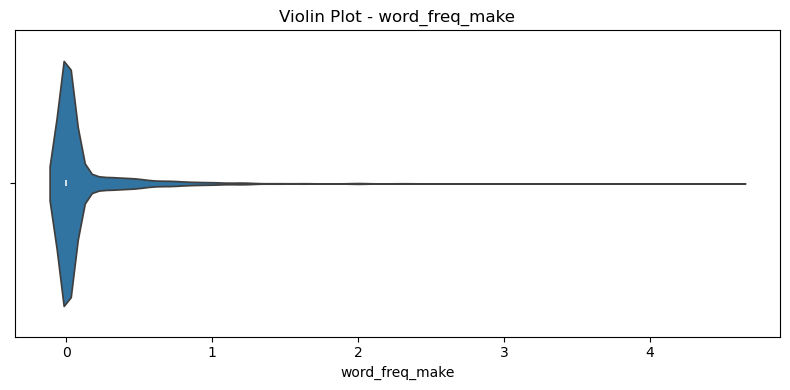

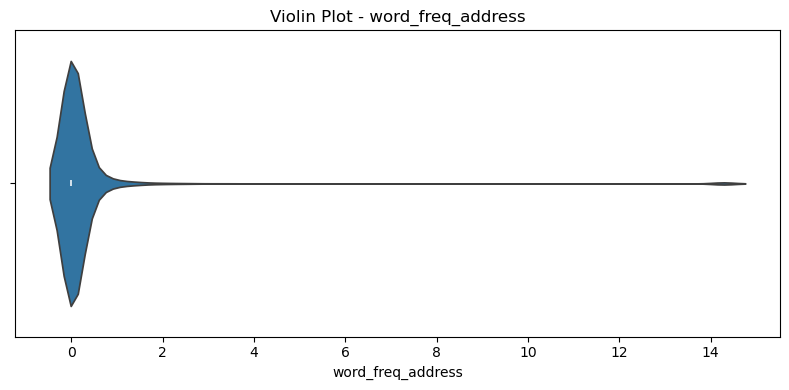

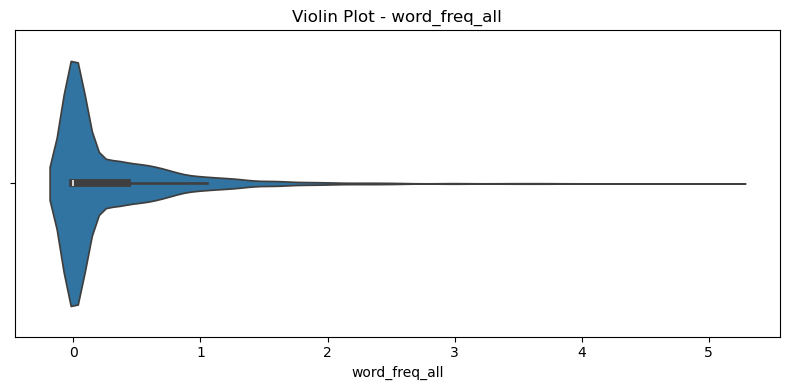

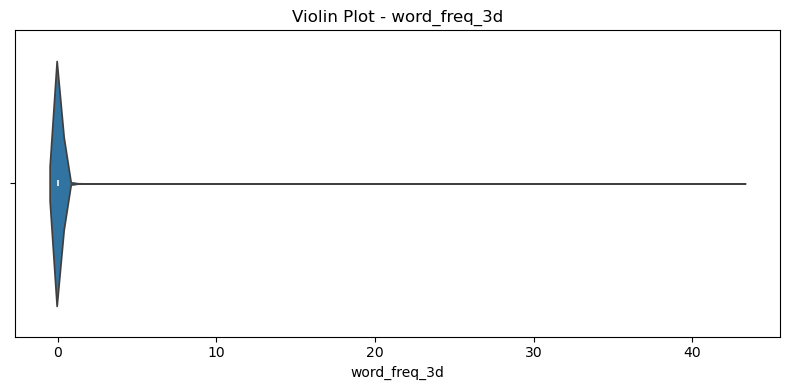

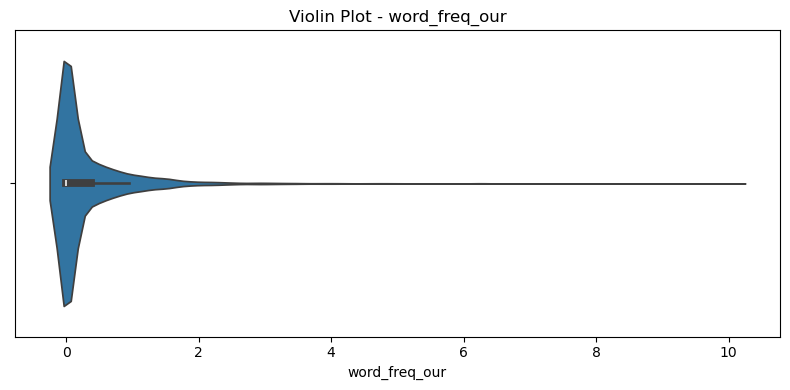

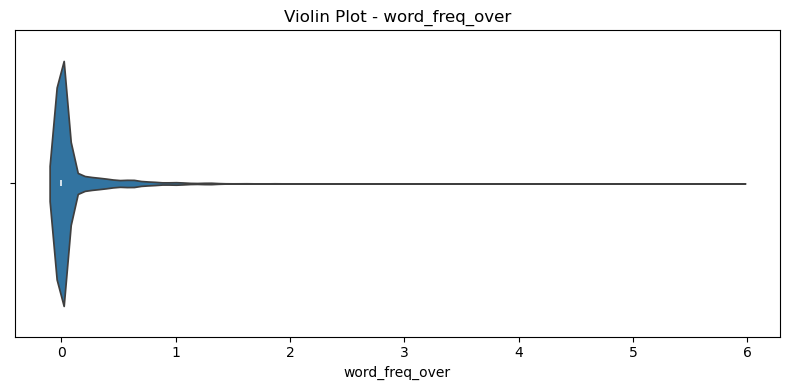

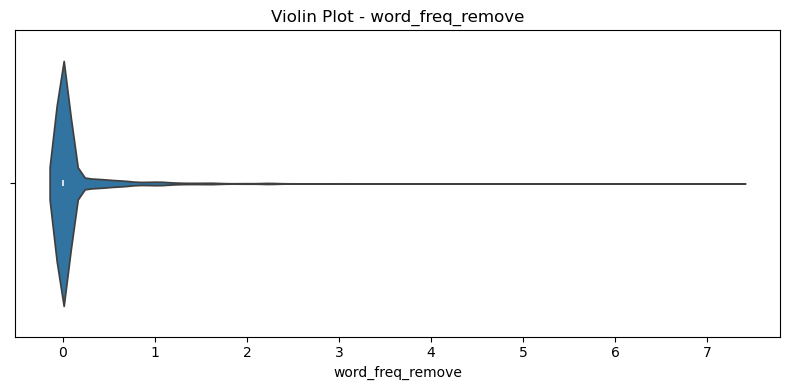

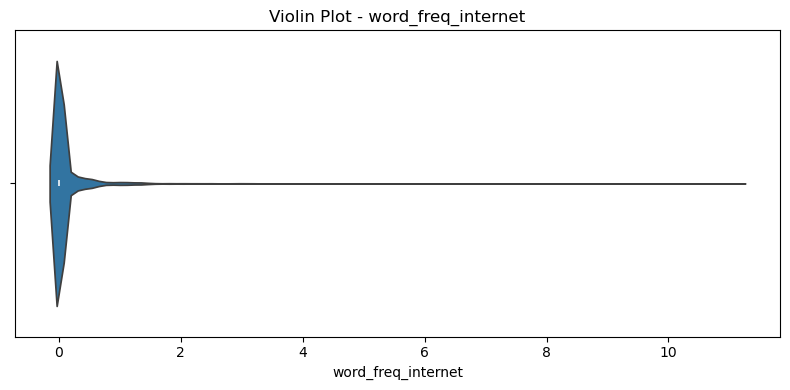

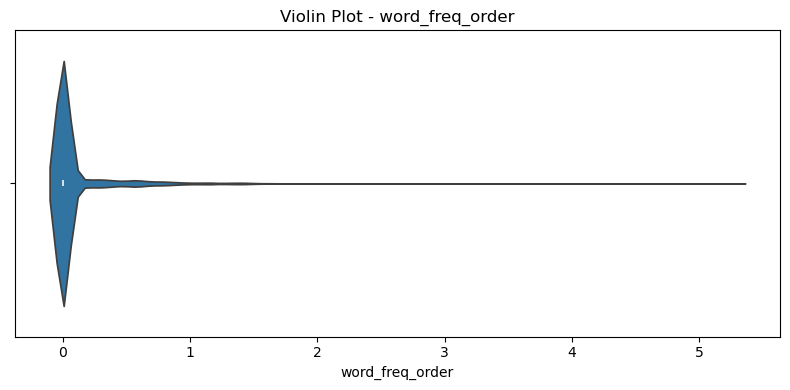

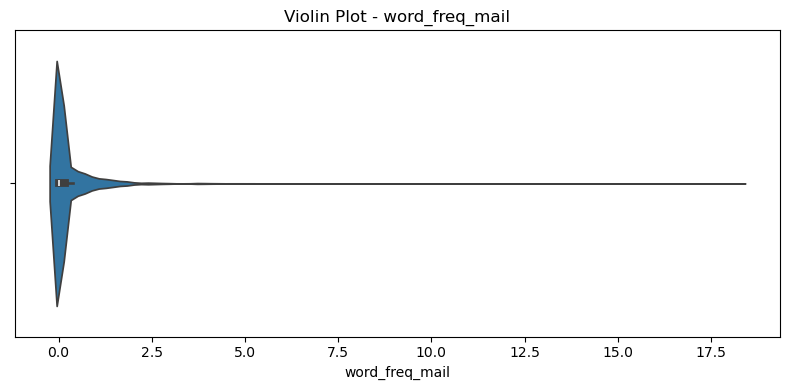

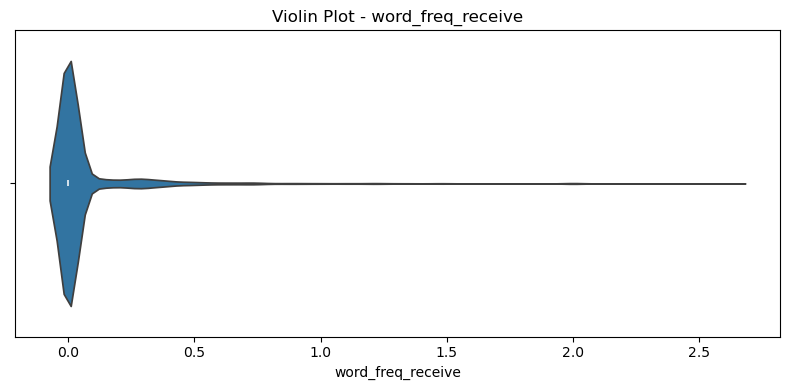

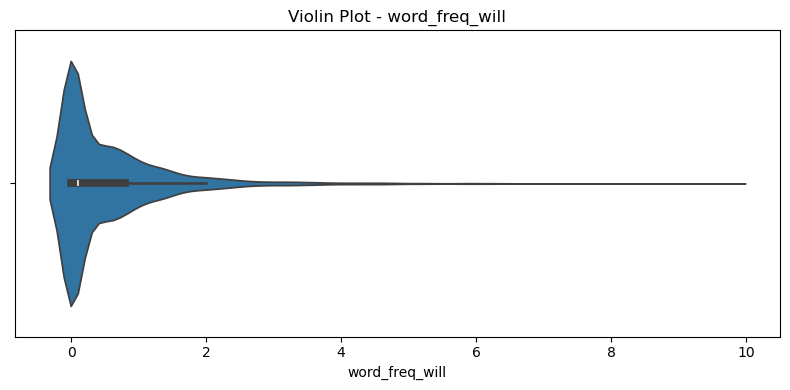

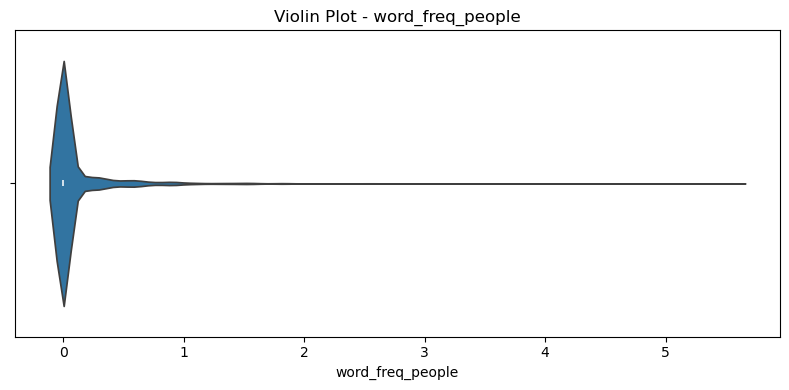

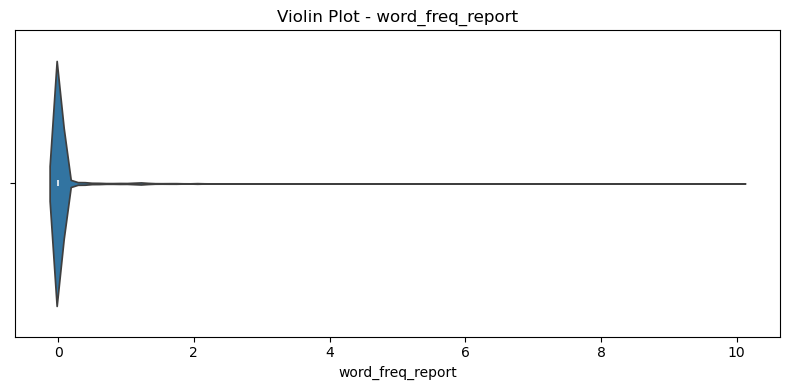

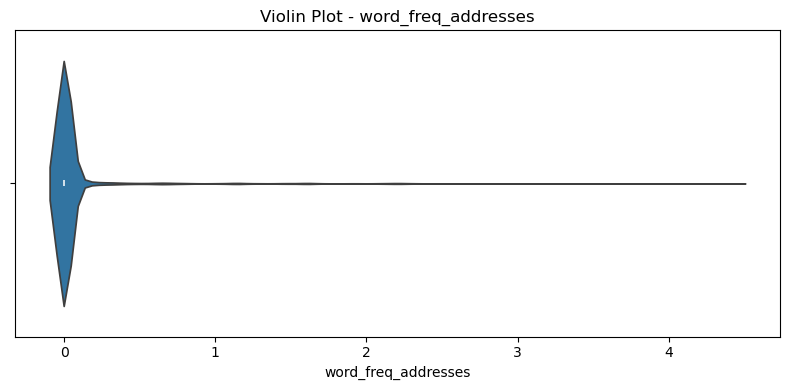

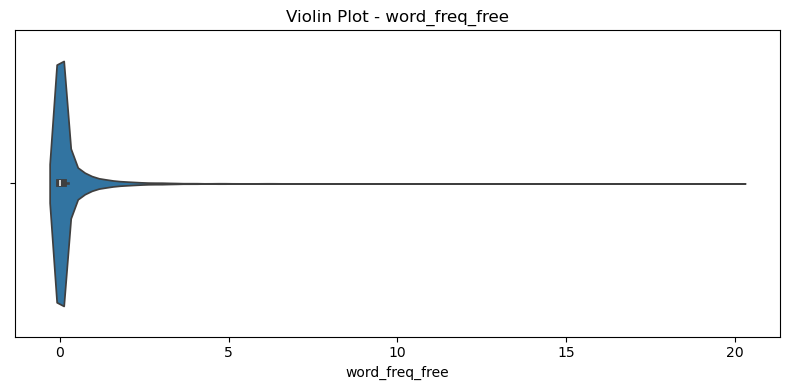

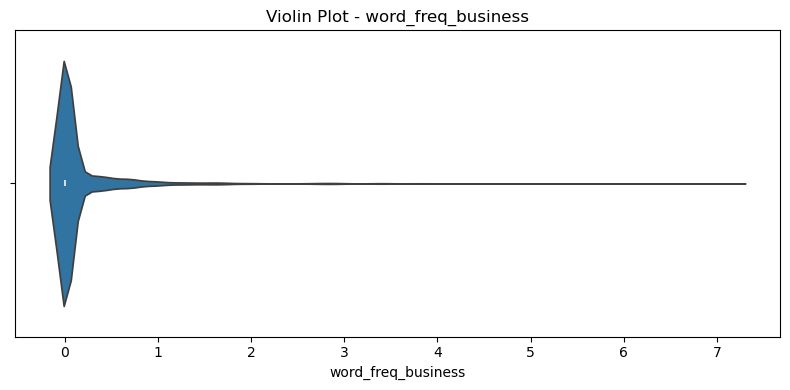

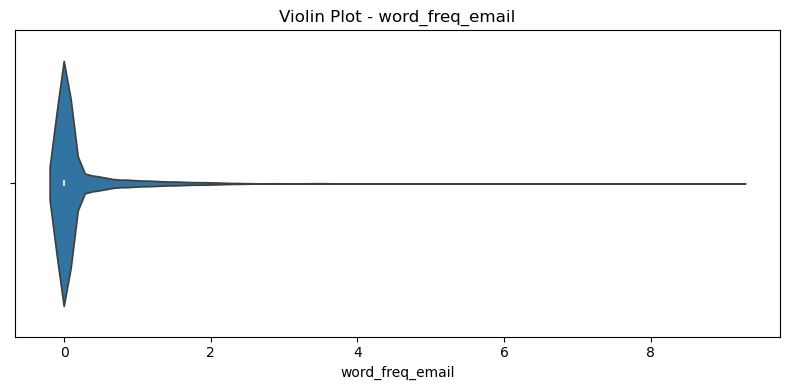

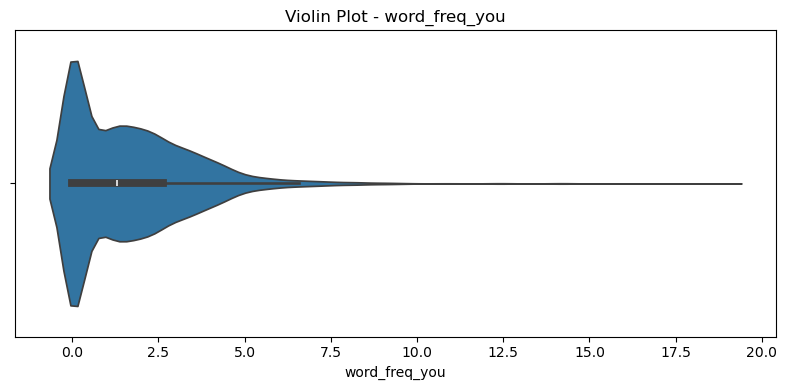

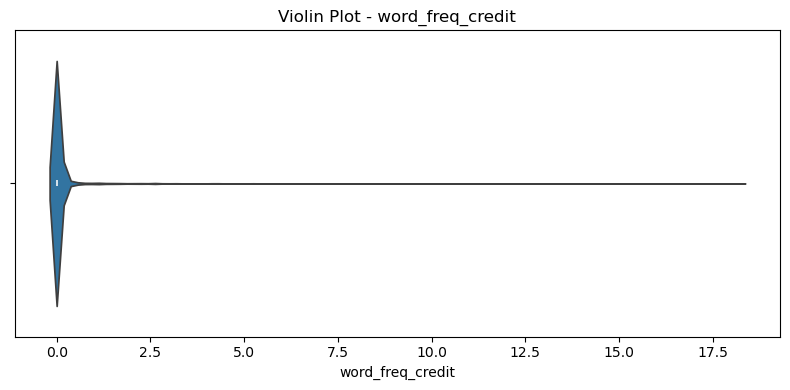


NUMERICAL FEATURE STATISTICS
                                  mean  median       variance         std  \
word_freq_make                0.104553   0.000       0.093243    0.305358   
word_freq_address             0.213015   0.000       1.665584    1.290575   
word_freq_all                 0.280656   0.000       0.254160    0.504143   
word_freq_3d                  0.065425   0.000       1.946447    1.395151   
word_freq_our                 0.312223   0.000       0.452273    0.672513   
word_freq_over                0.095901   0.000       0.074980    0.273824   
word_freq_remove              0.114208   0.000       0.153226    0.391441   
word_freq_internet            0.105295   0.000       0.160858    0.401071   
word_freq_order               0.090067   0.000       0.077627    0.278616   
word_freq_mail                0.239413   0.000       0.415710    0.644755   
word_freq_receive             0.059824   0.000       0.040620    0.201545   
word_freq_will                0.541702   0.100

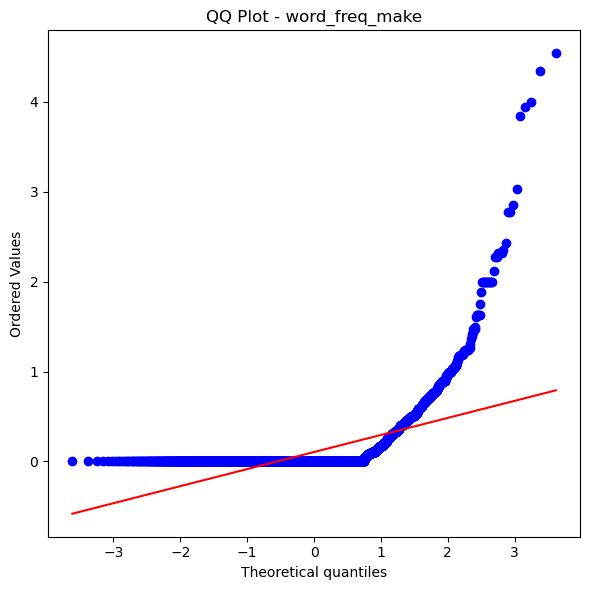

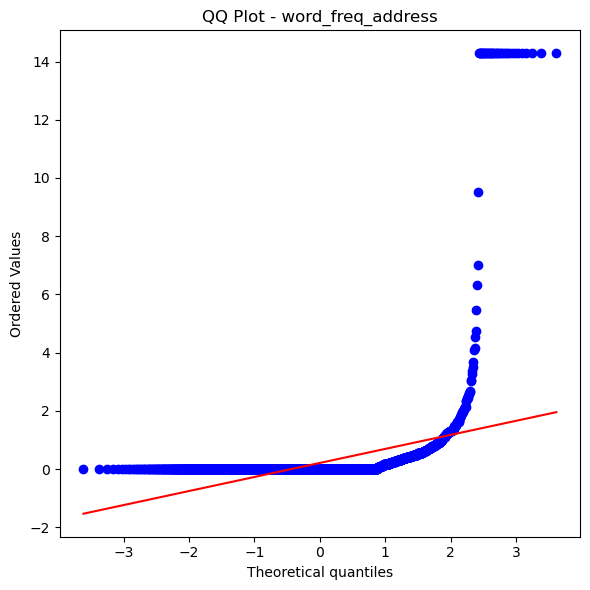

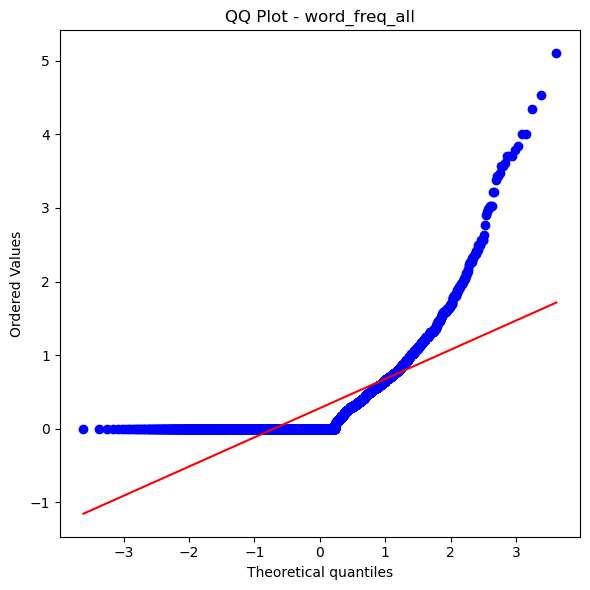

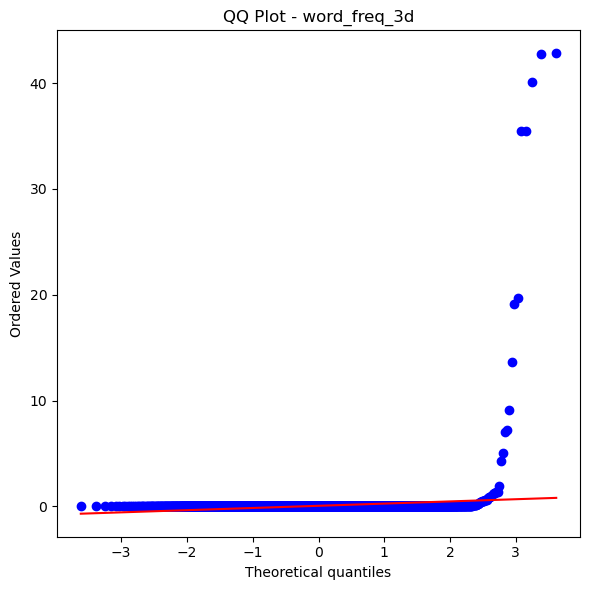

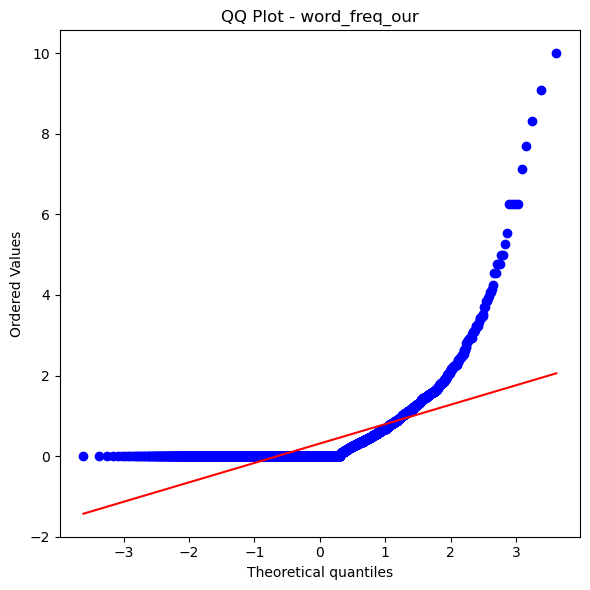

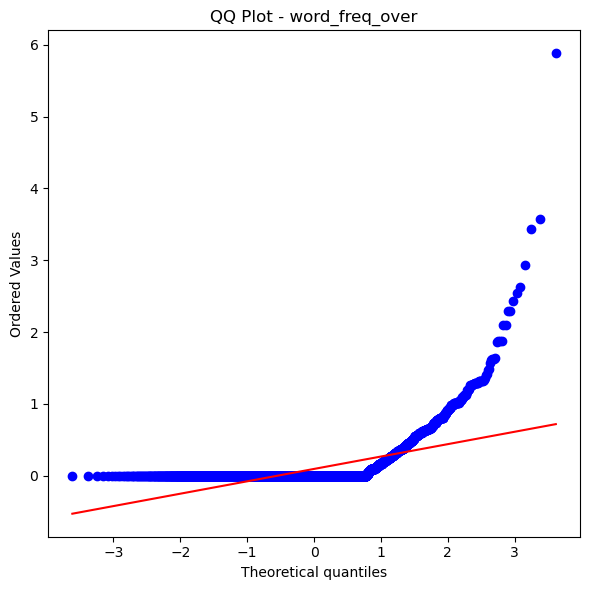

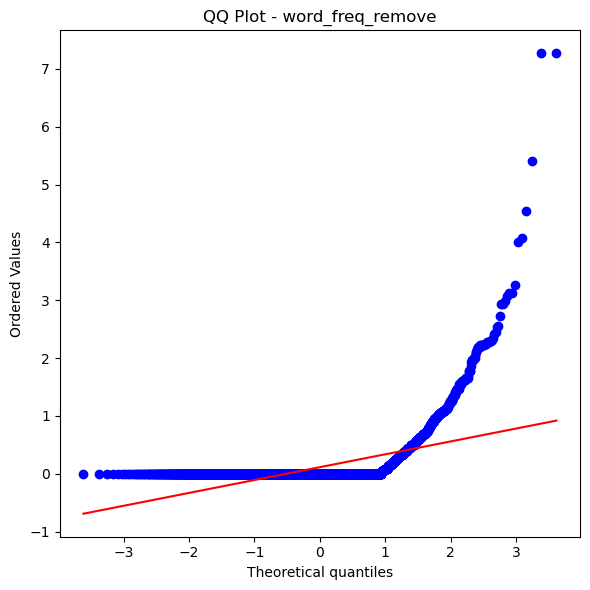

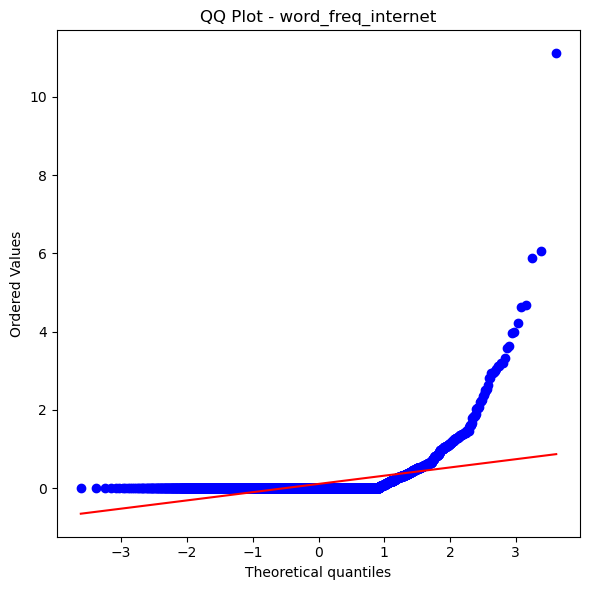

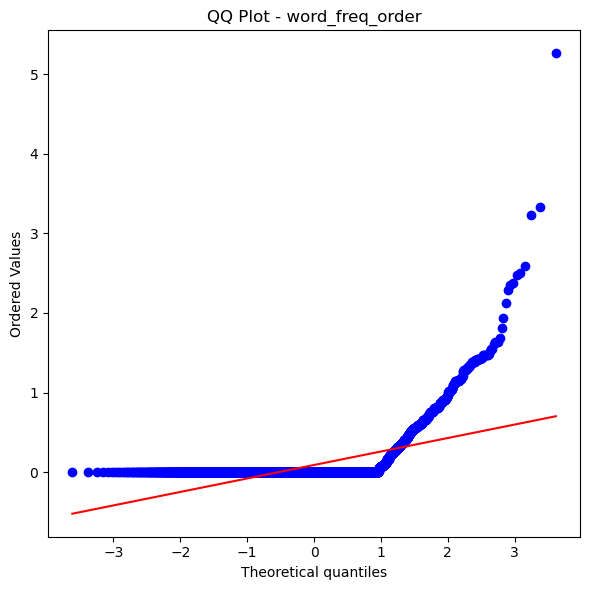

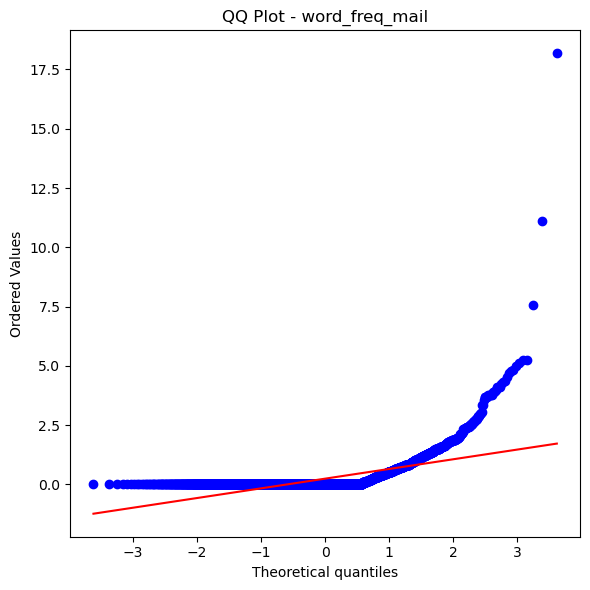

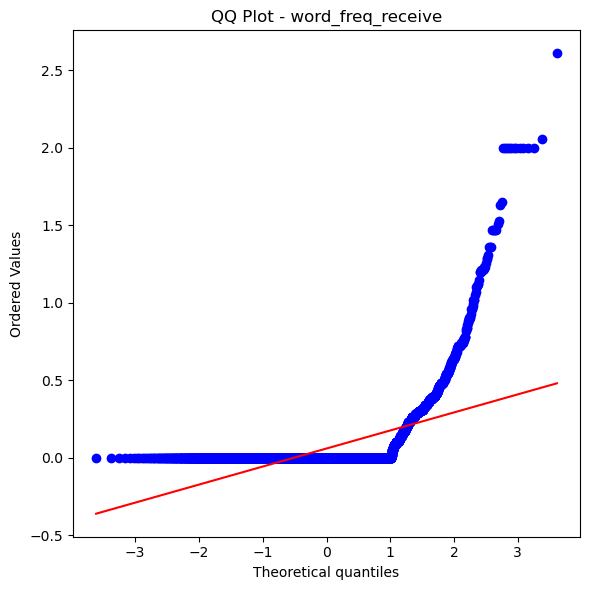

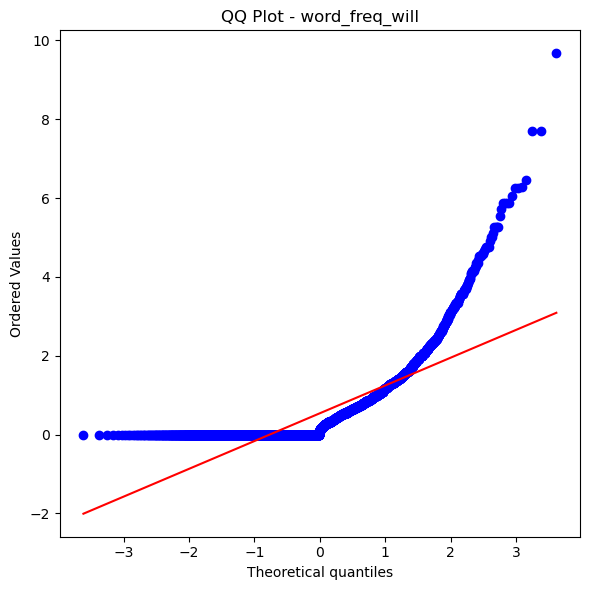

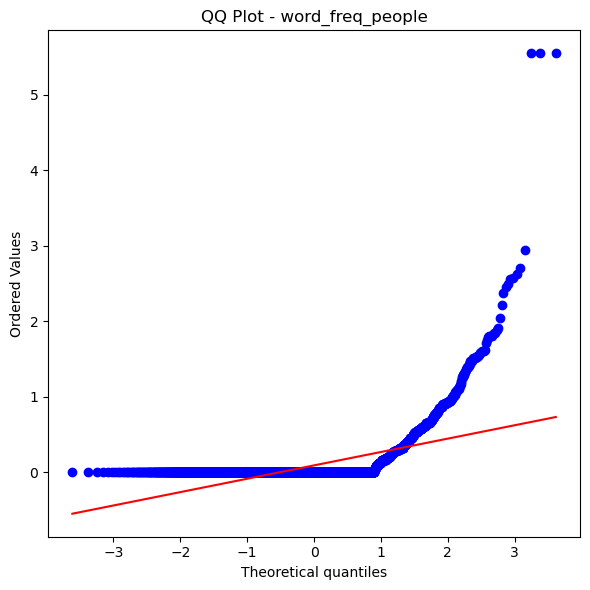

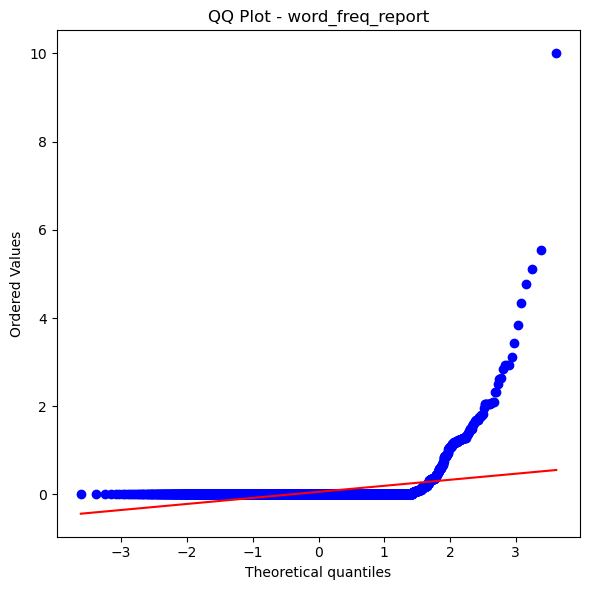

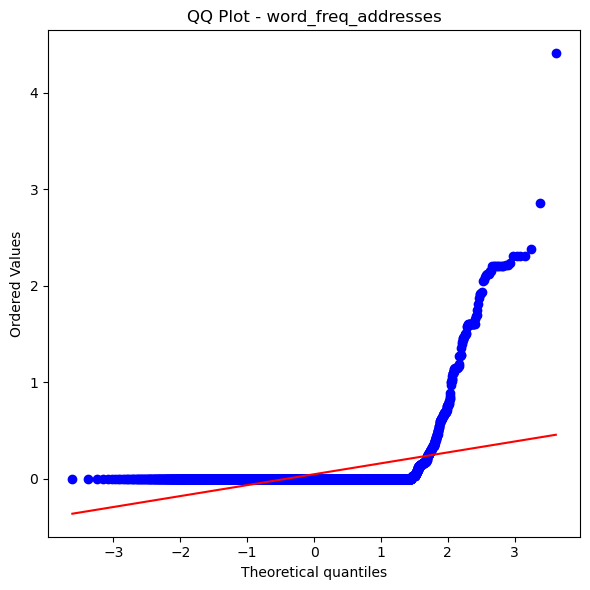

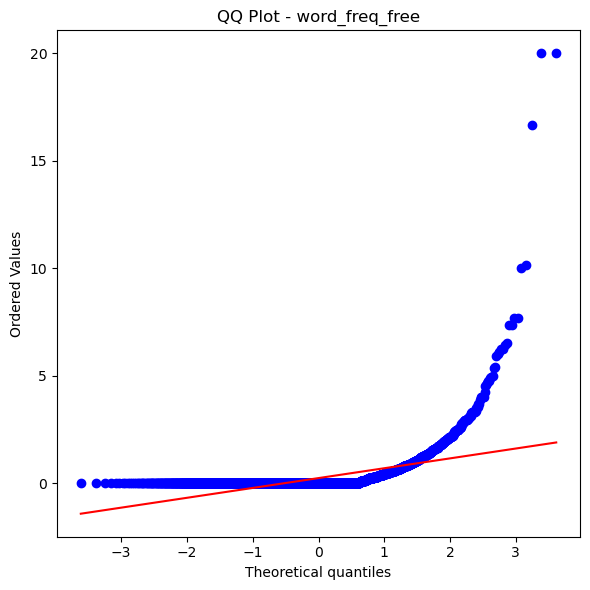

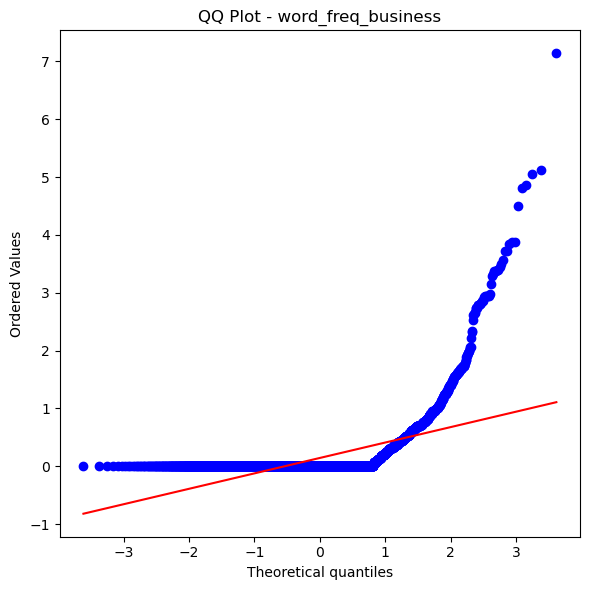

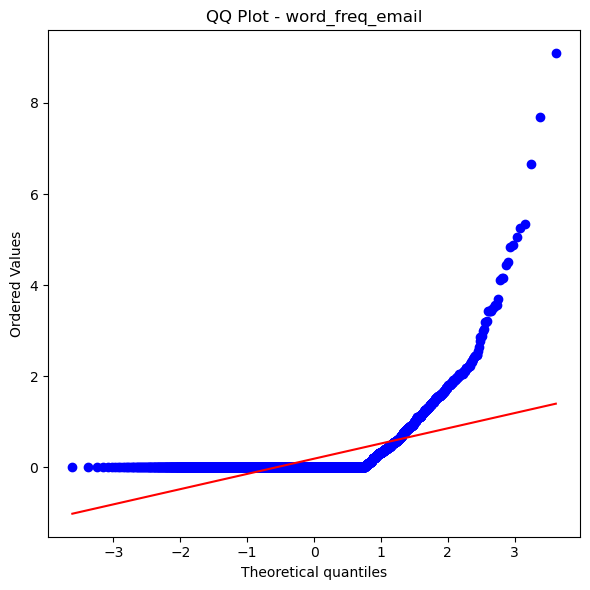

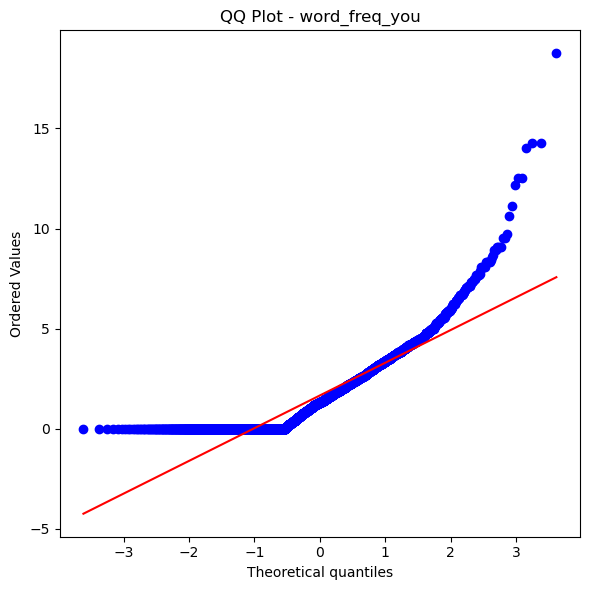

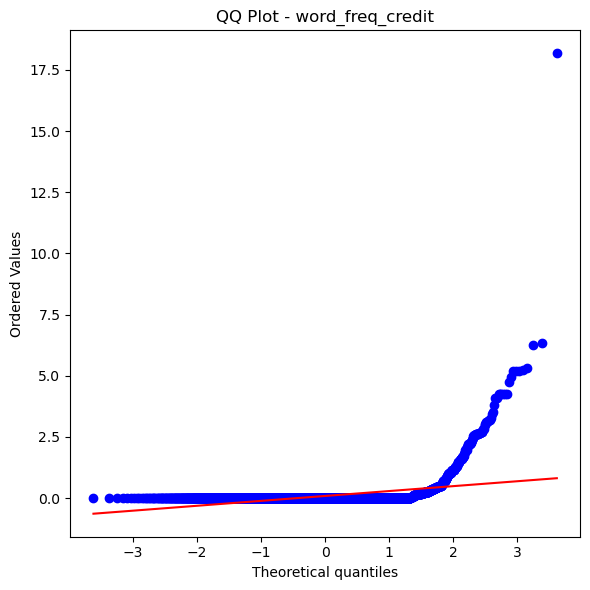


CORRELATION ANALYSIS


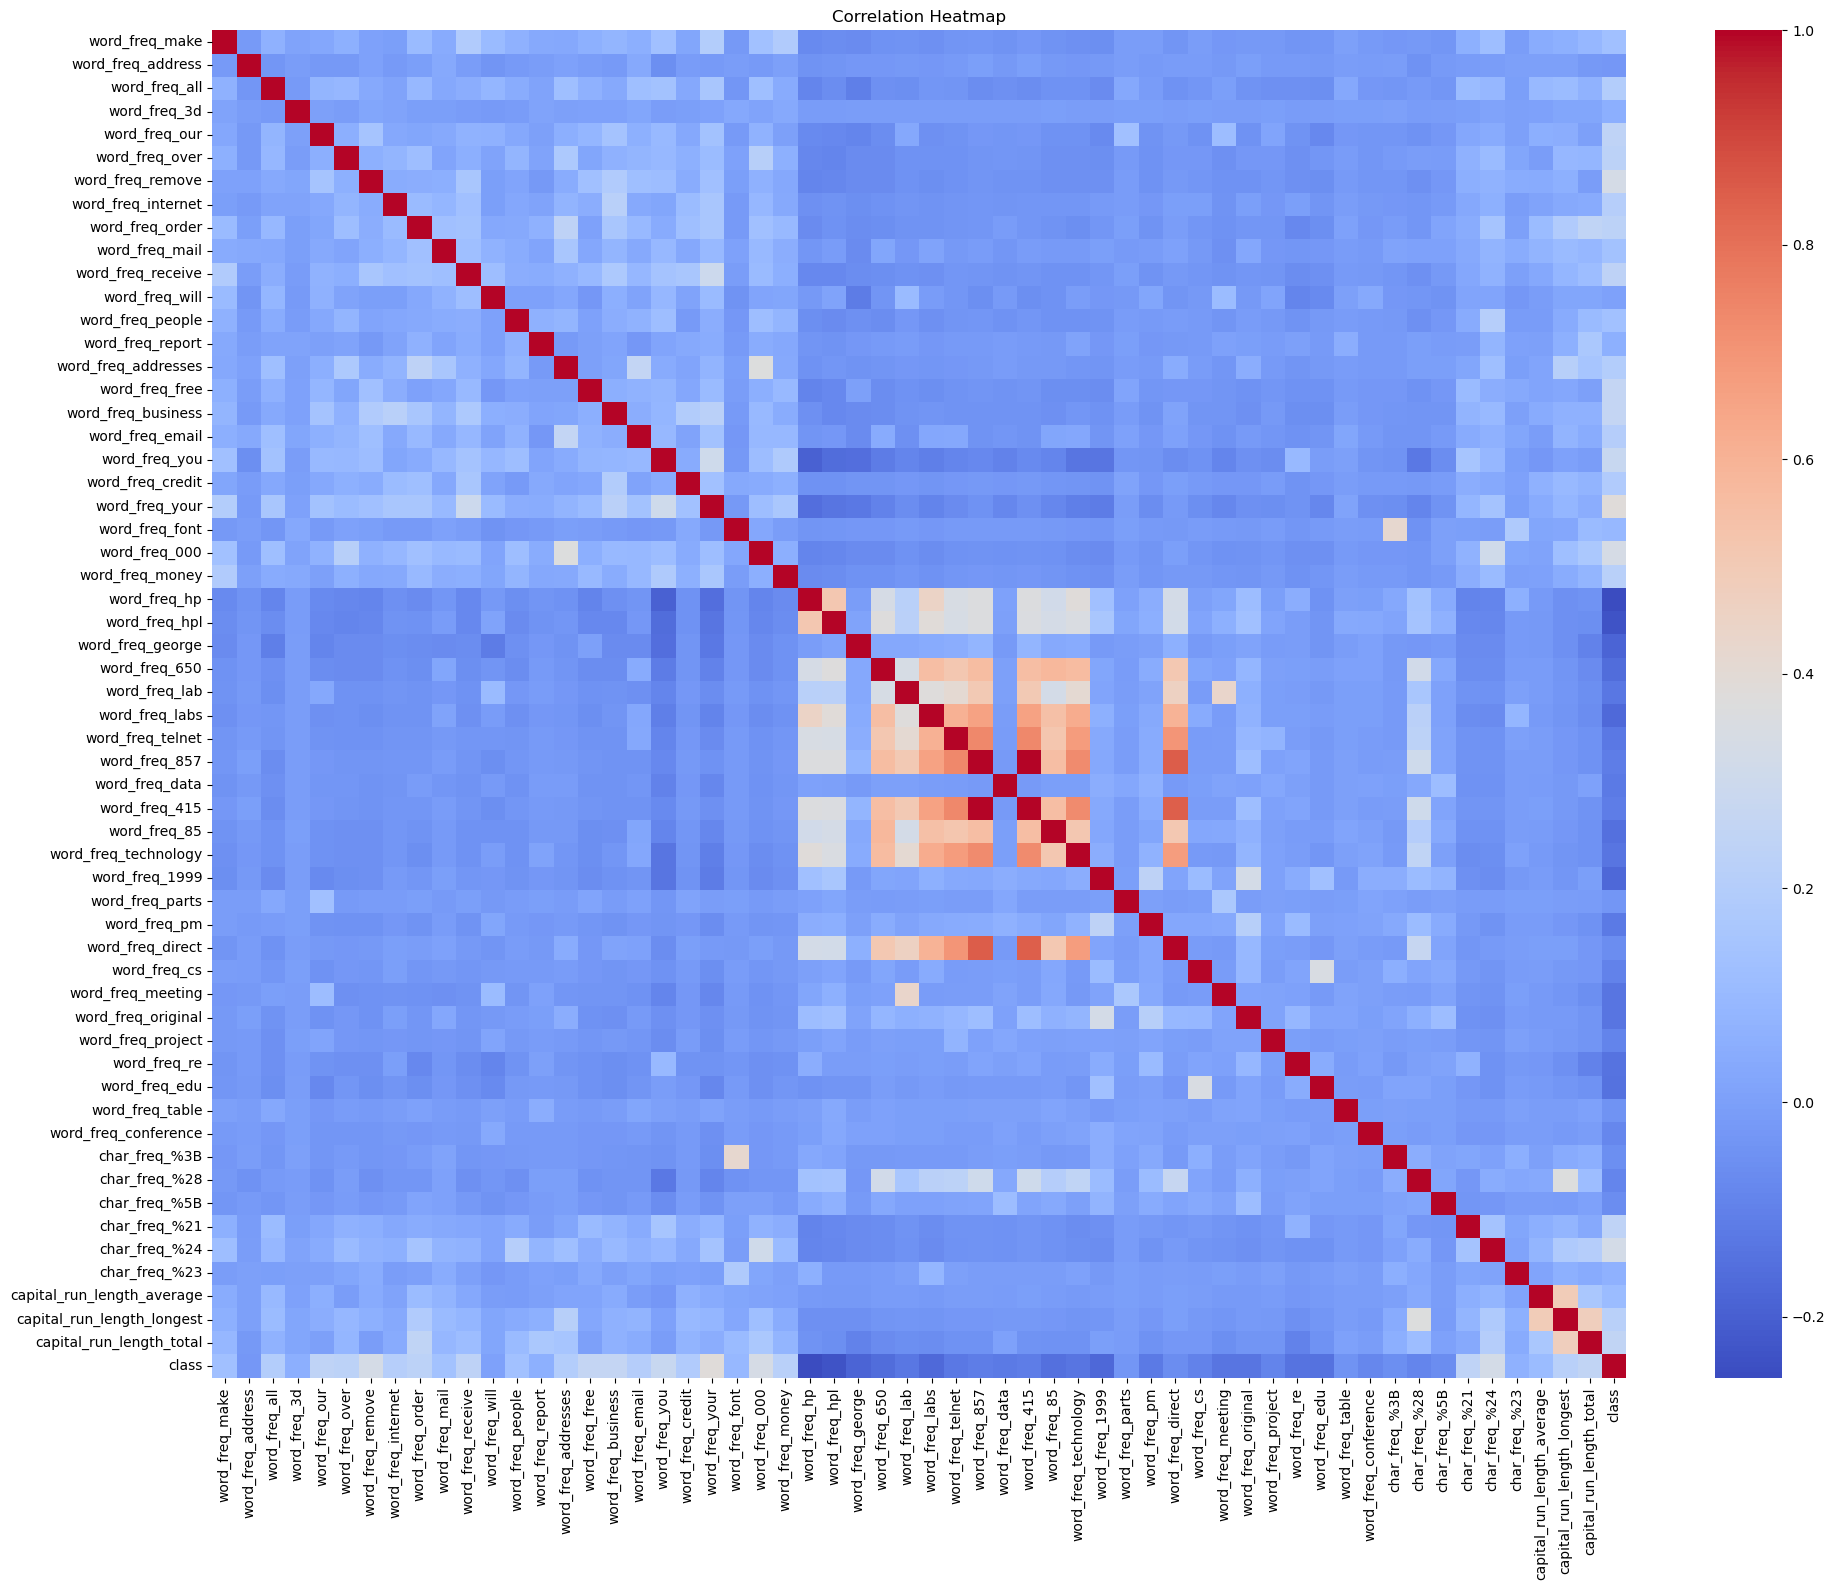


Correlation with target:
 word_freq_your                0.383234
word_freq_000                 0.334787
word_freq_remove              0.332117
char_freq_%24                 0.323629
word_freq_you                 0.273651
word_freq_free                0.263215
word_freq_business            0.263204
word_freq_hp                 -0.256723
capital_run_length_total      0.249164
word_freq_our                 0.241920
char_freq_%21                 0.241888
word_freq_receive             0.234529
word_freq_hpl                -0.232968
word_freq_over                0.232604
word_freq_order               0.231551
word_freq_money               0.216111
capital_run_length_longest    0.216097
word_freq_internet            0.206808
word_freq_email               0.204208
word_freq_all                 0.196988
word_freq_addresses           0.195902
word_freq_credit              0.189761
word_freq_george             -0.183404
word_freq_1999               -0.178045
word_freq_labs               -0.17109

In [11]:
perform_eda("/home/mtech1/Downloads/spambase_csv.xls")